#Proyecto final: Localización óptima de centros de acopio agrícola en Tamaulipas

$$
Materia: Cómputo Evolutivo.
$$
$$
Docente: Dr. Alan Díaz Manríquez.
$$
$$
Alumno: Gustavo Echeverria Salinas.
$$
$$
Fecha: 26 de Agosto de 2026.
$$


## 1. Introduccion

El presente proyecto aborda un problema de localización de infraestructura mediante técnicas de Computación Evolutiva. El caso de estudio consiste en seleccionar cabeceras municipales del estado de Tamaulipas como posibles ubicaciones para centros de acopio agrícola.

Cada municipio desempeña dos funciones dentro del problema: representa un punto de demanda asociado con su producción agrícola anual y, al mismo tiempo, constituye un sitio candidato para instalar un centro de acopio.

El objetivo general consiste en seleccionar un subconjunto de municipios donde instalar los centros, buscando reducir la distancia que debe recorrer la producción agrícola hasta el centro de acopio más cercano.

Para representar la importancia productiva de cada municipio se utiliza la producción anual de sorgo grano correspondiente al año 2024. Las distancias entre cabeceras municipales se calculan mediante la distancia geográfica Haversine.

Durante el proyecto se analizarán tres formulaciones:

1. Una formulación monoobjetivo, en la que se minimiza la distancia promedio ponderada por producción para un número fijo de centros.
2. Una formulación multiobjetivo con dos objetivos, donde se minimizan simultáneamente la distancia promedio ponderada y la distancia máxima de atención.
3. Una formulación multiobjetivo con tres objetivos, donde además se minimiza el número de centros instalados.

Para resolver estas formulaciones se utilizarán algoritmos evolutivos implementados mediante la biblioteca PYMOO, además de diferentes líneas base que permitirán comparar el desempeño de las soluciones obtenidas.

## 2. Preparacion del entorno

En esta sección se importan las bibliotecas necesarias para la lectura y procesamiento de los datos, análisis numérico, pruebas estadísticas, generación de gráficas e implementación de los algoritmos evolutivos y muestra de las versiones de Python y de las principales dependencias utilizadas.

### 2.1 Importacion de librerias

In [23]:
!pip install pymoo

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.7/72.7 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 64.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 328.3/328.3 kB 26.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 879.5/879.5 kB 51.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 6.8 MB/s eta 0:00:00


In [24]:
import sys
import os
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import scipy
from scipy.stats import wilcoxon

import pymoo

### 2.1 Congifuracion General

In [25]:
#(Configuracion General)

# Semilla base para reproducibilidad
SEMILLA_BASE = 42

random.seed(SEMILLA_BASE)
np.random.seed(SEMILLA_BASE)

# Mostrar más columnas y filas cuando sea necesario
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)


### 2.2 Verisones Del entorno

In [26]:
print("Versión de Python:", sys.version.split()[0])
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("SciPy:", scipy.__version__)
print("Matplotlib:", plt.matplotlib.__version__)
print("PYMOO:", pymoo.__version__)

Versión de Python: 3.13.15
NumPy: 2.1.3
Pandas: 2.2.3
SciPy: 1.16.3
Matplotlib: 3.10.0
PYMOO: 0.6.2


## 3. Carga de Datos
Para desarrollar el problema se utilizan dos archivos previamente procesados:

- `municipios_productores.csv`: contiene la clave INEGI, nombre, coordenadas geográficas y producción anual de sorgo grano de los 43 municipios de Tamaulipas.
- `distancias.csv`: contiene la distancia Haversine, expresada en kilómetros, entre cada par de cabeceras municipales.

En esta sección se cargan ambos conjuntos de datos y se realiza una primera inspección de su estructura.

In [27]:
from google.colab import files
uploaded = files.upload()


Saving distancias.csv to distancias.csv
Saving municipios_productores.csv to municipios_productores.csv


In [28]:
# Rutas de los archivos
RUTA_MUNICIPIOS = "municipios_productores.csv"
RUTA_DISTANCIAS = "distancias.csv"

# Cargar archivos CSV
municipios = pd.read_csv(RUTA_MUNICIPIOS)
distancias = pd.read_csv(RUTA_DISTANCIAS)

print("Archivos cargados correctamente.\n")

print("Dimensiones de municipios_productores.csv:")
print(municipios.shape)

print("\nDimensiones de distancias.csv:")
print(distancias.shape)

Archivos cargados correctamente.

Dimensiones de municipios_productores.csv:
(43, 5)

Dimensiones de distancias.csv:
(1849, 3)


### 3.1 Inspeccion de Municipios

In [29]:
print("Columnas:")
print(municipios.columns.tolist())

print("\nPrimeros registros:")
display(municipios.head())

print("\nInformación del DataFrame:")
municipios.info()

Columnas:
['clave_inegi', 'municipio', 'latitud', 'longitud', 'produccion_ton']

Primeros registros:


,clave_inegi,municipio,latitud,longitud,produccion_ton
0,28001,Abasolo,24.060837,-98.374278,18598.20
1,28002,Aldama,22.919305,-98.073712,41847.65
2,28003,Altamira,22.391553,-97.936687,59002.00
3,28004,Antiguo Morelos,22.549420,-99.083617,5.40
4,28005,Burgos,24.946639,-98.799010,4019.40



Información del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43 entries, 0 to 42
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   clave_inegi     43 non-null     int64  
 1   municipio       43 non-null     object 
 2   latitud         43 non-null     float64
 3   longitud        43 non-null     float64
 4   produccion_ton  43 non-null     float64
dtypes: float64(3), int64(1), object(1)
memory usage: 1.8+ KB


### 3.2 Inspeccion de Distancias

In [30]:
print("Columnas:")
print(distancias.columns.tolist())

print("\nPrimeros registros:")
display(distancias.head())

print("\nInformación del DataFrame:")
distancias.info()

Columnas:
['origen', 'destino', 'distancia_km']

Primeros registros:


,origen,destino,distancia_km
0,28001,28001,0.000000
1,28001,28002,130.581027
2,28001,28003,190.925447
3,28001,28004,183.007931
4,28001,28005,107.463336



Información del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1849 entries, 0 to 1848
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   origen        1849 non-null   int64  
 1   destino       1849 non-null   int64  
 2   distancia_km  1849 non-null   float64
dtypes: float64(1), int64(2)
memory usage: 43.5 KB


## 4. Construccion de Matriz de Distancias
Ahora vamos a convertir el CSV de 1849 filas en una matriz 43×43. Esta matriz será fundamental para prácticamente todos los algoritmos posteriores.

In [31]:
# Orden oficial de los municipios utilizado durante el proyecto
claves = municipios["clave_inegi"].to_numpy()

# Construir matriz origen × destino
matriz_distancias_df = (
    distancias
    .pivot(index="origen", columns="destino", values="distancia_km")
    .reindex(index=claves, columns=claves)
)

# Convertir a NumPy para los algoritmos de optimización
D = matriz_distancias_df.to_numpy()

print("Dimensiones de la matriz:", D.shape)

display(matriz_distancias_df.iloc[:5, :5])

Dimensiones de la matriz: (43, 43)


destino,28001,28002,28003,28004,28005
origen,,,,,
28001,0.000000,130.581027,190.925447,183.007931,107.463336
28002,130.581027,0.000000,60.344421,111.438943,237.174054
28003,190.925447,60.344421,0.000000,119.150070,297.372693
28004,183.007931,111.438943,119.150070,0.000000,268.127925
28005,107.463336,237.174054,297.372693,268.127925,0.000000


## 5. Analisis Exploratorio de datos

Se realiza un análisis exploratorio para conocer la distribución de la producción de sorgo grano entre los municipios de Tamaulipas y las características generales de las distancias entre sus cabeceras.

Se calcula la producción total estatal, el número de municipios con producción positiva y nula, los diez municipios con mayor producción y las principales estadísticas descriptivas de las distancias.

Este análisis permite identificar la concentración territorial de la producción antes de aplicar los métodos de optimización para la localización de los centros de acopio.

### 5.1 Analisis Exploratorio

In [32]:
produccion_total = municipios["produccion_ton"].sum()

municipios_positivos = (
    municipios["produccion_ton"] > 0
).sum()

municipios_cero = (
    municipios["produccion_ton"] == 0
).sum()

print("=" * 60)
print("PRODUCCIÓN AGRÍCOLA")
print("=" * 60)

print(f"\nProducción total estatal: {produccion_total:,.2f} toneladas")
print(f"Municipios con producción positiva: {municipios_positivos}")
print(f"Municipios con producción cero:     {municipios_cero}")

PRODUCCIÓN AGRÍCOLA

Producción total estatal: 2,097,659.12 toneladas
Municipios con producción positiva: 34
Municipios con producción cero:     9


### 5.2 Municipios con mayor produccion

In [33]:
top10 = (
    municipios
    .sort_values("produccion_ton", ascending=False)
    .head(10)
    [["clave_inegi", "municipio", "produccion_ton"]]
    .reset_index(drop=True)
)

# Numeración desde 1
top10.index = top10.index + 1
top10.index.name = "Posición"

print("Diez municipios con mayor producción de sorgo grano:")
display(top10)

Diez municipios con mayor producción de sorgo grano:


,clave_inegi,municipio,produccion_ton
Posición,,,
1,28022,Matamoros,404951.40
2,28033,Río Bravo,379515.22
3,28035,San Fernando,377455.95
4,28032,Reynosa,259270.15
5,28040,Valle Hermoso,211199.00
6,28023,Méndez,118100.70
7,28012,González,63936.25
8,28003,Altamira,59002.00
9,28002,Aldama,41847.65


### 5.3 Estadisticas de las distancias

In [34]:
# Extraer únicamente distancias entre municipios distintos,
# contando cada pareja una sola vez.
indices_superiores = np.triu_indices_from(D, k=1)

distancias_unicas = D[indices_superiores]

dist_min = np.min(distancias_unicas)
dist_media = np.mean(distancias_unicas)
dist_mediana = np.median(distancias_unicas)
dist_max = np.max(distancias_unicas)

print("=" * 60)
print("DISTANCIAS ENTRE CABECERAS MUNICIPALES")
print("=" * 60)

print(f"\nNúmero de pares únicos: {len(distancias_unicas)}")
print(f"Distancia mínima:       {dist_min:.3f} km")
print(f"Distancia media:        {dist_media:.3f} km")
print(f"Distancia mediana:      {dist_mediana:.3f} km")
print(f"Distancia máxima:       {dist_max:.3f} km")

DISTANCIAS ENTRE CABECERAS MUNICIPALES

Número de pares únicos: 903
Distancia mínima:       4.017 km
Distancia media:        202.234 km
Distancia mediana:      180.794 km
Distancia máxima:       609.189 km


### 5.3 Distribucion de las distancias

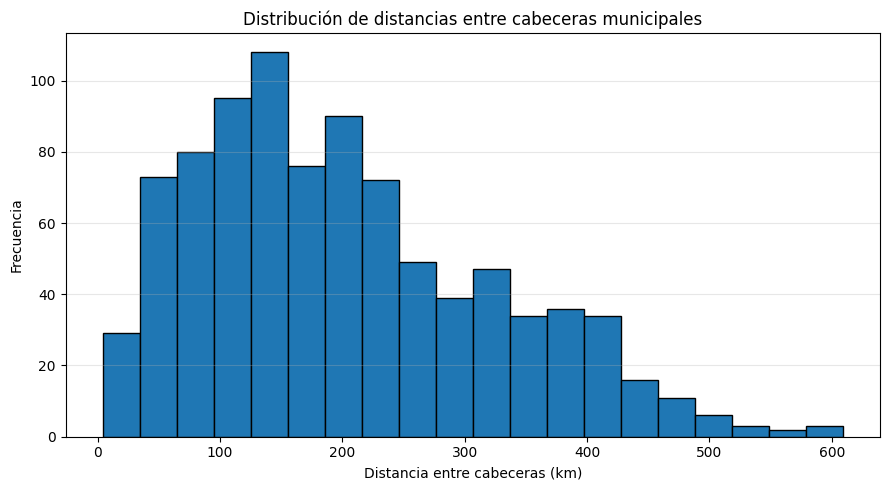

In [35]:
plt.figure(figsize=(9, 5))

plt.hist(
    distancias_unicas,
    bins=20,
    edgecolor="black"
)

plt.xlabel("Distancia entre cabeceras (km)")
plt.ylabel("Frecuencia")
plt.title("Distribución de distancias entre cabeceras municipales")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Formulacion del Problema

Cada solución se representa mediante un vector binario de longitud 43:

$$
x=[x_1,x_2,\ldots,x_{43}]
$$

donde:

$
x_j =
\begin{cases}
1, & \text{si se instala un centro de acopio en el municipio } j \\
0, & \text{en caso contrario}
\end{cases}
$

En la formulación monoobjetivo se establece un número fijo de centros $p$, por lo que cada solución debe cumplir:

$$
\sum_{j=1}^{43}x_j=p
$$

Para cada municipio productor $i$, se determina la distancia al centro de acopio seleccionado más cercano:

$$
d_i^{\min}=\min_{j:x_j=1}d_{ij}
$$

La función objetivo corresponde a la distancia promedio ponderada por la producción:

$$
f(x)=
\frac{\sum_{i=1}^{43}P_i d_i^{\min}}
{\sum_{i=1}^{43}P_i}
$$

donde $P_i$ representa la producción anual del municipio $i$ y $d_i^{\min}$ la distancia desde dicho municipio hasta el centro seleccionado más cercano.

El objetivo consiste en minimizar $f(x)$. De esta manera, los municipios con mayor producción tienen una mayor influencia sobre la solución.

### 6.1 Preparar Vectores

In [36]:
# Vector de producción
P = municipios["produccion_ton"].to_numpy(dtype=float)

# Número de municipios
N = len(municipios)

# Producción total
PRODUCCION_TOTAL = P.sum()

print(f"Número de municipios: {N}")
print(f"Dimensiones de P: {P.shape}")
print(f"Dimensiones de D: {D.shape}")
print(f"Producción total: {PRODUCCION_TOTAL:,.2f} toneladas")

Número de municipios: 43
Dimensiones de P: (43,)
Dimensiones de D: (43, 43)
Producción total: 2,097,659.12 toneladas


### 6.2 Funcion de Evaluacion

In [37]:
def evaluar_solucion(x):

    x = np.asarray(x, dtype=int)

    # Verificar dimensiones
    if len(x) != N:
        raise ValueError(
            f"La solución debe contener {N} posiciones."
        )

    # Obtener índices de los centros seleccionados
    centros = np.where(x == 1)[0]

    # Debe existir al menos un centro
    if len(centros) == 0:
        return np.inf

    # Para cada municipio, buscar la distancia
    # al centro seleccionado más cercano
    distancias_minimas = np.min(
        D[:, centros],
        axis=1
    )

    # Distancia promedio ponderada
    fitness = np.sum(
        P * distancias_minimas
    ) / PRODUCCION_TOTAL

    return fitness

### 6.3 Funcion para obtener nombres de los puntos

In [38]:
def obtener_centros(x):
    """
    Obtiene los municipios seleccionados como centros
    a partir de una solución binaria.
    """

    indices = np.where(np.asarray(x) == 1)[0]

    return municipios.iloc[indices][
        ["clave_inegi", "municipio", "produccion_ton"]
    ].reset_index(drop=True)

# Prueba

In [39]:
# ============================================================
# PRUEBA DE LA FUNCIÓN OBJETIVO
# ============================================================

p_prueba = 3

# Crear solución inicialmente vacía
x_prueba = np.zeros(N, dtype=int)

# Seleccionar los primeros 3 municipios
x_prueba[:p_prueba] = 1

print("Vector de solución:")
print(x_prueba)

print(f"\nNúmero de centros: {x_prueba.sum()}")

print("\nCentros seleccionados:")
display(obtener_centros(x_prueba))

fitness_prueba = evaluar_solucion(x_prueba)

print(
    f"Distancia promedio ponderada: "
    f"{fitness_prueba:.4f} km"
)

Vector de solución:
[1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0]

Número de centros: 3

Centros seleccionados:


,clave_inegi,municipio,produccion_ton
0,28001,Abasolo,18598.20
1,28002,Aldama,41847.65
2,28003,Altamira,59002.00


Distancia promedio ponderada: 160.6583 km


### 6.4 Ver Cabecera asignada

In [40]:
def obtener_asignaciones(x):
    """
    Determina el centro seleccionado más cercano
    para cada municipio.
    """

    centros = np.where(np.asarray(x) == 1)[0]

    if len(centros) == 0:
        raise ValueError("La solución no contiene centros.")

    # Distancias hacia los centros seleccionados
    distancias_centros = D[:, centros]

    # Posición del centro más cercano
    posiciones_minimas = np.argmin(
        distancias_centros,
        axis=1
    )

    # Índices originales de los centros asignados
    centros_asignados = centros[posiciones_minimas]

    # Distancias mínimas
    distancias_minimas = np.min(
        distancias_centros,
        axis=1
    )

    resultado = pd.DataFrame({
        "municipio": municipios["municipio"],
        "produccion_ton": P,
        "centro_asignado":
            municipios.iloc[centros_asignados]["municipio"].to_numpy(),
        "distancia_km": distancias_minimas
    })

    return resultado

# Prueba

In [41]:
asignaciones_prueba = obtener_asignaciones(x_prueba)

display(asignaciones_prueba.head(10))

,municipio,produccion_ton,centro_asignado,distancia_km
0,Abasolo,18598.20,Abasolo,0.000000
1,Aldama,41847.65,Aldama,0.000000
2,Altamira,59002.00,Altamira,0.000000
3,Antiguo Morelos,5.40,Aldama,111.438943
4,Burgos,4019.40,Abasolo,107.463336
5,Bustamante,0.00,Abasolo,157.047163
6,Camargo,14948.76,Abasolo,255.108414
7,Casas,39250.00,Abasolo,52.374072
8,Ciudad Madero,0.00,Altamira,19.133679
9,Cruillas,1092.00,Abasolo,78.893511


La evaluación de una solución consiste primero en identificar los municipios seleccionados como centros de acopio. Posteriormente, cada uno de los 43 municipios se asigna al centro seleccionado cuya cabecera se encuentra a menor distancia.

La distancia resultante se pondera mediante la producción agrícola del municipio. Por esta razón, una distancia elevada asociada con un municipio de alta producción tiene un efecto mayor sobre la función objetivo que la misma distancia asociada con un municipio de baja producción.

El valor obtenido se expresa en kilómetros y representa la distancia promedio ponderada que debe recorrer la producción hasta el centro de acopio seleccionado más cercano. En consecuencia, valores menores de la función objetivo representan mejores soluciones.

## 7. Líneas base

Antes de aplicar los algoritmos evolutivos se implementan diferentes líneas base para establecer valores de referencia con los cuales comparar las soluciones obtenidas.

Se consideran tres estrategias:

1. **Selección aleatoria:** seleccionar $p$ municipios al azar y evaluar la solución obtenida. Se realizan 30 corridas independientes utilizando semillas fijas.
2. **Selección por producción:** seleccionar los $p$ municipios con mayor producción agrícola.
3. **Heurística voraz:** construir progresivamente la solución seleccionando, en cada iteración, el municipio que produzca la mayor reducción de la función objetivo.

Las tres estrategias se evalúan para:

$$
p \in \{3,5,7,10\}
$$

donde $p$ representa el número de centros de acopio instalados.

### 7.1 Configuracion de Pruebas

In [42]:
VALORES_P = [3, 5, 7, 10]

# 30 semillas fijas para reproducibilidad
SEMILLAS = list(range(30))

print("Valores de p:", VALORES_P)
print("Número de corridas:", len(SEMILLAS))
print("Semillas:", SEMILLAS)

Valores de p: [3, 5, 7, 10]
Número de corridas: 30
Semillas: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]


### 7.2 Creacion de Linea Aleatorio

In [43]:
def solucion_aleatoria(p, semilla):

    rng = np.random.default_rng(semilla)

    # Seleccionar p índices diferentes
    indices = rng.choice(
        N,
        size=p,
        replace=False
    )

    # Construir vector binario
    x = np.zeros(N, dtype=int)
    x[indices] = 1

    return x

# Prueba

In [44]:
x_aleatoria = solucion_aleatoria(
    p=3,
    semilla=0
)

print(x_aleatoria)
print("\nNúmero de centros:", x_aleatoria.sum())

display(obtener_centros(x_aleatoria))

print(
    "Fitness:",
    evaluar_solucion(x_aleatoria)
)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0
 0 0 0 0 0 0]

Número de centros: 3


,clave_inegi,municipio,produccion_ton
0,28022,Matamoros,404951.40
1,28027,Nuevo Laredo,0.00
2,28035,San Fernando,377455.95


Fitness: 57.747378470967156


### 7.3 Prueba de Ejecutar 30 corridas

In [45]:
resultados_aleatorios = []

for p in VALORES_P:

    for semilla in SEMILLAS:

        x = solucion_aleatoria(
            p=p,
            semilla=semilla
        )

        fitness = evaluar_solucion(x)

        centros = obtener_centros(x)["municipio"].tolist()

        resultados_aleatorios.append({
            "p": p,
            "semilla": semilla,
            "fitness": fitness,
            "centros": ", ".join(centros)
        })


df_aleatorio = pd.DataFrame(
    resultados_aleatorios
)

print(
    "Número total de experimentos:",
    len(df_aleatorio)
)

display(df_aleatorio.head())

Número total de experimentos: 120


,p,semilla,fitness,centros
0,3,0,57.747378,"Matamoros, Nuevo Laredo, San Fernando"
1,3,1,65.755279,"Mainero, Matamoros, Río Bravo"
2,3,2,92.501505,"Burgos, Gómez Farías, San Fernando"
3,3,3,142.902416,"Antiguo Morelos, Casas, San Carlos"
4,3,4,57.894640,"Padilla, Tampico, Valle Hermoso"


### 7.4 Estadistica de prueba

In [46]:
resumen_aleatorio = (
    df_aleatorio
    .groupby("p")["fitness"]
    .agg(
        mejor="min",
        media="mean",
        mediana="median",
        desviacion_estandar="std",
        peor="max"
    )
    .reset_index()
)

display(
    resumen_aleatorio.round(4)
)

,p,mejor,media,mediana,desviacion_estandar,peor
0,3,57.7474,120.1782,113.2604,48.5230,260.5787
1,5,30.1046,78.4490,84.2067,31.6149,146.7157
2,7,25.5551,73.9715,62.8880,45.6008,201.7318
3,10,19.2124,48.7267,43.3944,20.6387,106.1778


In [47]:
indices_mejores = (
    df_aleatorio
    .groupby("p")["fitness"]
    .idxmin()
)

mejores_aleatorias = (
    df_aleatorio
    .loc[indices_mejores]
    .sort_values("p")
    .reset_index(drop=True)
)

display(mejores_aleatorias)

,p,semilla,fitness,centros
0,3,0,57.747378,"Matamoros, Nuevo Laredo, San Fernando"
1,5,16,30.104638,"Llera, Matamoros, Méndez, Río Bravo, San Carlos"
2,7,26,25.555132,"Altamira, Cruillas, Hidalgo, Jaumave, Llera, M..."
3,10,7,19.212390,"Altamira, Cruillas, Güémez, Matamoros, Miguel ..."


### 7.4 ¿Que es Heuristica?

es un conjunto de estrategias, reglas prácticas o atajos mentales que permiten resolver problemas y tomar decisiones de forma rápida cuando no se dispone de información completa o tiempo suficiente.

En este caso nos quedaremos con lo $p$ municipios con mayor produccion como centros de acopio y cada municipio se le asigana el centro de acopio mas cercano a este.

### 7.5 Heuristica por produccion

El concepto de heurística por producción se define como un conjunto de reglas empíricas, lógicas y simplificadas que se aplican para resolver problemas complejos de toma de decisiones en la gestión de operaciones y manufactura.A diferencia de los algoritmos matemáticos tradicionales, este concepto se fundamenta en los siguientes pilares:

* **Suficiencia sobre optimización:** No busca la mejor solución absoluta (óptima), sino una solución lo suficientemente buena y viable bajo restricciones de tiempo y recursos.

* **Reducción de complejidad:** Transforma problemas de alta dificultad computacional (como la secuenciación de cientos de tareas en varias máquinas) en decisiones paso a paso guiadas por el sentido común y la experiencia técnica.

* **Reglas de despacho (Priority Rules):** Estructura el flujo de trabajo mediante criterios lógicos prefijados (por ejemplo, priorizar la tarea que vence primero o la que requiere menos tiempo de preparación).



In [48]:
def solucion_por_produccion(p):

    # Índices ordenados de mayor a menor producción
    indices = np.argsort(P)[::-1][:p]

    x = np.zeros(N, dtype=int)
    x[indices] = 1

    return x

**Ejecutamos los 4 casos**

In [49]:


resultados_produccion = []

for p in VALORES_P:

    x = solucion_por_produccion(p)

    fitness = evaluar_solucion(x)

    centros = obtener_centros(x)["municipio"].tolist()

    resultados_produccion.append({
        "p": p,
        "fitness": fitness,
        "centros": ", ".join(centros)
    })


df_produccion = pd.DataFrame(
    resultados_produccion
)

display(df_produccion)

,p,fitness,centros
0,3,38.903461,"Matamoros, Río Bravo, San Fernando"
1,5,31.902908,"Matamoros, Reynosa, Río Bravo, San Fernando, V..."
2,7,10.296874,"González, Matamoros, Méndez, Reynosa, Río Brav..."
3,10,3.793611,"Aldama, Altamira, Casas, González, Matamoros, ..."


### 7.6 Heuristica Voraz

La heurística voraz (también conocida como algoritmo glotón o greedy heuristic) es un método de resolución de problemas que toma la mejor decisión local en cada paso con la esperanza de encontrar la solución óptima global.En términos sencillos, elige la opción que parece más atractiva o beneficiosa en el momento presente, sin evaluar las consecuencias futuras ni dar marcha atrás.

* **Elección miope:** Analiza únicamente los elementos disponibles en el paso actual y toma el que maximice la ganancia o minimice el costo inmediato.

* **Irreversible:** Una vez que toma una decisión e incluye un elemento en la solución, este nunca se cambia ni se reconsidera.

* **Eficiencia:** Es extremadamente rápida y consume pocos recursos computacionales.

* **Sin garantía de optimilidad:** Aunque suele encontrar soluciones aceptables

muy rápido, a menudo no logra la solución perfecta global porque no planifica a largo plazo.

In [50]:
def solucion_voraz(p):

    seleccionados = []

    for _ in range(p):

        mejor_candidato = None
        mejor_fitness = np.inf

        # Probar todos los municipios todavía no seleccionados
        for candidato in range(N):

            if candidato in seleccionados:
                continue

            prueba = seleccionados + [candidato]

            x = np.zeros(N, dtype=int)
            x[prueba] = 1

            fitness = evaluar_solucion(x)

            if fitness < mejor_fitness:

                mejor_fitness = fitness
                mejor_candidato = candidato

        # Agregar el mejor municipio encontrado
        seleccionados.append(
            mejor_candidato
        )

    # Construir solución binaria final
    x = np.zeros(N, dtype=int)
    x[seleccionados] = 1

    return x

#Prueba

In [51]:
resultados_voraz = []

for p in VALORES_P:

    x = solucion_voraz(p)

    fitness = evaluar_solucion(x)

    centros = obtener_centros(x)["municipio"].tolist()

    resultados_voraz.append({
        "p": p,
        "fitness": fitness,
        "centros": ", ".join(centros)
    })


df_voraz = pd.DataFrame(
    resultados_voraz
)

display(df_voraz)

,p,fitness,centros
0,3,38.022956,"González, San Fernando, Valle Hermoso"
1,5,16.621667,"González, Matamoros, Río Bravo, San Fernando, ..."
2,7,9.639805,"Casas, González, Matamoros, Méndez, Río Bravo,..."
3,10,3.721809,"Altamira, Casas, González, Matamoros, Méndez, ..."


### 7.7 Comparacion Previa

In [52]:
comparacion_base = pd.DataFrame({
    "p": VALORES_P,

    "Aleatorio_media": [
        df_aleatorio[
            df_aleatorio["p"] == p
        ]["fitness"].mean()
        for p in VALORES_P
    ],

    "Produccion": [
        df_produccion[
            df_produccion["p"] == p
        ]["fitness"].iloc[0]
        for p in VALORES_P
    ],

    "Voraz": [
        df_voraz[
            df_voraz["p"] == p
        ]["fitness"].iloc[0]
        for p in VALORES_P
    ]
})

display(
    comparacion_base.round(4)
)

,p,Aleatorio_media,Produccion,Voraz
0,3,120.1782,38.9035,38.0230
1,5,78.4490,31.9029,16.6217
2,7,73.9715,10.2969,9.6398
3,10,48.7267,3.7936,3.7218


# grafica

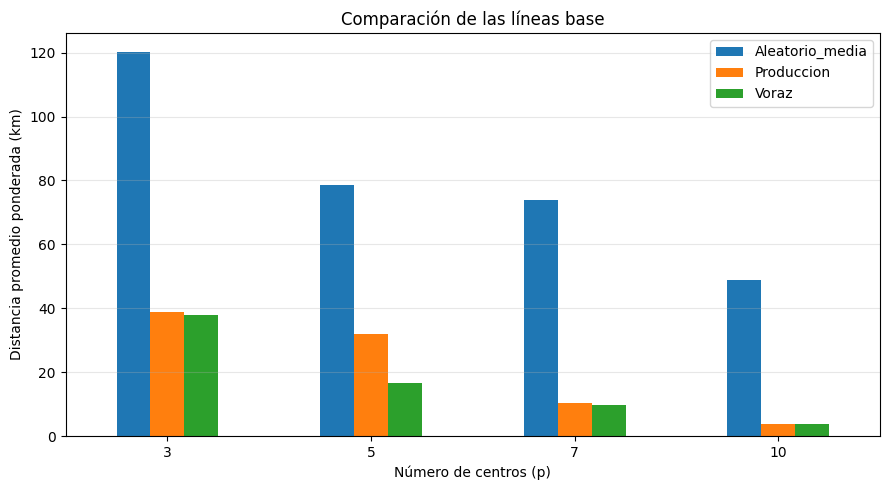

In [53]:
comparacion_base.set_index("p")[
    ["Aleatorio_media", "Produccion", "Voraz"]
].plot(
    kind="bar",
    figsize=(9, 5)
)

plt.xlabel("Número de centros (p)")
plt.ylabel("Distancia promedio ponderada (km)")
plt.title("Comparación de las líneas base")

plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## 7.8 interpretacion

Las líneas base permiten establecer referencias para evaluar posteriormente el desempeño del algoritmo genético.

La selección aleatoria representa una estrategia sin conocimiento previo sobre la producción o distribución geográfica de los municipios. Debido a su naturaleza estocástica, se realizan 30 corridas independientes para analizar la variabilidad de sus resultados.

La heurística por producción prioriza los municipios con mayor volumen agrícola. Sin embargo, esta estrategia no considera directamente las distancias entre municipios, por lo que una alta concentración de centros en una misma región puede producir una cobertura territorial limitada.

La heurística voraz incorpora directamente la función objetivo durante la construcción de la solución. En cada iteración selecciona el municipio cuya incorporación genera el menor valor de distancia promedio ponderada.

Estas líneas base servirán como referencia para determinar si el algoritmo genético es capaz de encontrar soluciones de mayor calidad.

## 8. Algoritmo Genetico Monobjetivo

Para resolver el problema monoobjetivo se implementa un algoritmo genético mediante la biblioteca PYMOO.

Cada individuo se representa mediante un vector binario de 43 posiciones, donde un valor de 1 indica la instalación de un centro de acopio en el municipio correspondiente.

Para cada valor de:

$$
p \in \{3,5,7,10\}
$$

se exige seleccionar exactamente $p$ centros:

$$
\sum_{j=1}^{43}x_j=p
$$

Debido a que los operadores genéticos pueden producir individuos que no satisfagan esta restricción, se implementa un mecanismo de reparación. Si existen más de $p$ centros, se desactivan posiciones seleccionadas aleatoriamente; si existen menos de $p$, se activan posiciones disponibles hasta recuperar la cardinalidad requerida.

La calidad de cada individuo se evalúa mediante la distancia promedio ponderada por producción definida anteriormente.

### 8.1 Importacion de PYMOO

In [54]:
from pymoo.core.problem import ElementwiseProblem
from pymoo.core.repair import Repair

from pymoo.algorithms.soo.nonconvex.ga import GA

from pymoo.operators.sampling.rnd import BinaryRandomSampling
from pymoo.operators.crossover.pntx import TwoPointCrossover
from pymoo.operators.mutation.bitflip import BitflipMutation

from pymoo.optimize import minimize

### 8.2 Definir problema

In [55]:
class ProblemaCentrosAcopio(ElementwiseProblem):

    def __init__(self, p):

        self.p = p

        super().__init__(
            n_var=N,
            n_obj=1,
            n_ieq_constr=0,
            xl=0,
            xu=1
        )

    def _evaluate(self, x, out, *args, **kwargs):

        # Convertir la solución a binaria
        x = np.asarray(x).astype(int)

        # Evaluar distancia promedio ponderada
        fitness = evaluar_solucion(x)

        out["F"] = fitness

### 8.3 Operdor de Reparacion

In [56]:
class ReparacionCardinalidad(Repair):

    def __init__(self, p):

        super().__init__()

        self.p = p

    def _do(self, problem, X, **kwargs):

        X = X.astype(bool)

        for i in range(len(X)):

            seleccionados = np.where(X[i])[0]
            no_seleccionados = np.where(~X[i])[0]

            # Si existen más centros de los permitidos
            if len(seleccionados) > self.p:

                eliminar = np.random.choice(
                    seleccionados,
                    size=len(seleccionados) - self.p,
                    replace=False
                )

                X[i, eliminar] = False

            # Si existen menos centros de los requeridos
            elif len(seleccionados) < self.p:

                agregar = np.random.choice(
                    no_seleccionados,
                    size=self.p - len(seleccionados),
                    replace=False
                )

                X[i, agregar] = True

        return X

### 8.4 Parametros Experimentales

In [57]:
POBLACION_GA = 100
GENERACIONES_GA = 200

PROB_CRUCE = 0.90
PROB_MUTACION = 1.0 / N

CORRIDAS_GA = 30

SEMILLAS_GA = list(range(CORRIDAS_GA))

print("Población:", POBLACION_GA)
print("Generaciones:", GENERACIONES_GA)
print("Probabilidad de cruce:", PROB_CRUCE)
print("Probabilidad de mutación:", PROB_MUTACION)
print("Corridas:", CORRIDAS_GA)

Población: 100
Generaciones: 200
Probabilidad de cruce: 0.9
Probabilidad de mutación: 0.023255813953488372
Corridas: 30


### 8.5 Funcion para Algoritmo Genetico

In [58]:
def ejecutar_ga(p, semilla):

    problema = ProblemaCentrosAcopio(p)

    algoritmo = GA(
        pop_size=POBLACION_GA,

        sampling=BinaryRandomSampling(),

        crossover=TwoPointCrossover(
            prob=PROB_CRUCE
        ),

        mutation=BitflipMutation(
            prob=PROB_MUTACION
        ),

        repair=ReparacionCardinalidad(p),

        eliminate_duplicates=True
    )

    resultado = minimize(
        problema,
        algoritmo,
        termination=(
            "n_gen",
            GENERACIONES_GA
        ),
        seed=semilla,
        verbose=False
    )

    # Mejor solución
    x = np.asarray(
        resultado.X
    ).astype(int)

    fitness = float(
        np.asarray(resultado.F).flatten()[0]
    )

    return x, fitness

### 8.6 Primera Prueba

In [59]:
x_ga_prueba, fitness_ga_prueba = ejecutar_ga(
    p=3,
    semilla=0
)

print("=" * 60)
print("PRUEBA DEL ALGORITMO GENÉTICO")
print("=" * 60)

print(
    f"\nNúmero de centros: "
    f"{x_ga_prueba.sum()}"
)

print(
    f"Fitness: "
    f"{fitness_ga_prueba:.4f} km"
)

print("\nCentros seleccionados:")

display(
    obtener_centros(
        x_ga_prueba
    )
)

PRUEBA DEL ALGORITMO GENÉTICO

Número de centros: 3
Fitness: 32.5614 km

Centros seleccionados:


,clave_inegi,municipio,produccion_ton
0,28012,González,63936.25
1,28033,Río Bravo,379515.22
2,28035,San Fernando,377455.95


### 8.7 Comprobar la Restriccion

In [60]:
assert x_ga_prueba.sum() == 3, \
    "El GA produjo una solución que viola la cardinalidad."

print(
    "Restricción de cardinalidad cumplida correctamente."
)

Restricción de cardinalidad cumplida correctamente.


### 8.8 Ejecucion

Para analizar el comportamiento del algoritmo genético se realizan 30 corridas independientes para cada número de centros:

$$
p \in \{3,5,7,10\}
$$

Se utilizan las mismas semillas ($0,\ldots,29$) para mantener la reproducibilidad del experimento. En cada corrida se registra la mejor distancia promedio ponderada encontrada y los municipios seleccionados como centros de acopio.

La utilización de múltiples corridas permite analizar no solamente la mejor solución encontrada, sino también la estabilidad y variabilidad del algoritmo.

In [61]:
resultados_ga = []

for p in VALORES_P:

    print(f"\nEjecutando GA para p = {p}")

    for semilla in SEMILLAS_GA:

        x, fitness = ejecutar_ga(
            p=p,
            semilla=semilla
        )

        # Comprobar cardinalidad
        assert x.sum() == p

        centros = obtener_centros(x)[
            "municipio"
        ].tolist()

        resultados_ga.append({
            "p": p,
            "semilla": semilla,
            "fitness": fitness,
            "centros": ", ".join(centros)
        })

        print(
            f"  Semilla {semilla:02d} | "
            f"Fitness = {fitness:.4f} km"
        )

print("\nExperimento finalizado.")


Ejecutando GA para p = 3
  Semilla 00 | Fitness = 32.5614 km
  Semilla 01 | Fitness = 32.5614 km
  Semilla 02 | Fitness = 32.5614 km
  Semilla 03 | Fitness = 32.5614 km
  Semilla 04 | Fitness = 32.5614 km
  Semilla 05 | Fitness = 32.5614 km
  Semilla 06 | Fitness = 32.5614 km
  Semilla 07 | Fitness = 32.5614 km
  Semilla 08 | Fitness = 32.5614 km
  Semilla 09 | Fitness = 32.5614 km
  Semilla 10 | Fitness = 32.5614 km
  Semilla 11 | Fitness = 32.5614 km
  Semilla 12 | Fitness = 32.5614 km
  Semilla 13 | Fitness = 32.5614 km
  Semilla 14 | Fitness = 32.5614 km
  Semilla 15 | Fitness = 32.5614 km
  Semilla 16 | Fitness = 32.5614 km
  Semilla 17 | Fitness = 32.5614 km
  Semilla 18 | Fitness = 32.5614 km
  Semilla 19 | Fitness = 32.5614 km
  Semilla 20 | Fitness = 32.5614 km
  Semilla 21 | Fitness = 32.5614 km
  Semilla 22 | Fitness = 32.5614 km
  Semilla 23 | Fitness = 32.5614 km
  Semilla 24 | Fitness = 32.5614 km
  Semilla 25 | Fitness = 32.5614 km
  Semilla 26 | Fitness = 32.5614 km
  

### Conversion de Datos a df

In [62]:
df_ga = pd.DataFrame(
    resultados_ga
)

print(
    "Número total de corridas:",
    len(df_ga)
)

display(
    df_ga.head(10)
)

Número total de corridas: 120


,p,semilla,fitness,centros
0,3,0,32.561412,"González, Río Bravo, San Fernando"
1,3,1,32.561412,"González, Río Bravo, San Fernando"
2,3,2,32.561412,"González, Río Bravo, San Fernando"
3,3,3,32.561412,"González, Río Bravo, San Fernando"
4,3,4,32.561412,"González, Río Bravo, San Fernando"
5,3,5,32.561412,"González, Río Bravo, San Fernando"
6,3,6,32.561412,"González, Río Bravo, San Fernando"
7,3,7,32.561412,"González, Río Bravo, San Fernando"
8,3,8,32.561412,"González, Río Bravo, San Fernando"
9,3,9,32.561412,"González, Río Bravo, San Fernando"


# Resultado Estadistico

In [63]:
resumen_ga = (
    df_ga
    .groupby("p")["fitness"]
    .agg(
        mejor="min",
        media="mean",
        mediana="median",
        desviacion_estandar="std",
        peor="max"
    )
    .reset_index()
)

print("Resultados del algoritmo genético:")

display(
    resumen_ga.round(4)
)


Resultados del algoritmo genético:


,p,mejor,media,mediana,desviacion_estandar,peor
0,3,32.5614,32.5614,32.5614,0.0,32.5614
1,5,16.6217,16.6217,16.6217,0.0,16.6217
2,7,9.6398,9.6398,9.6398,0.0,9.6398
3,10,3.7218,3.7218,3.7218,0.0,3.7218


### 8.9 Mejores Individuos

In [64]:

indices_mejores_ga = (
    df_ga
    .groupby("p")["fitness"]
    .idxmin()
)

mejores_ga = (
    df_ga
    .loc[indices_mejores_ga]
    .sort_values("p")
    .reset_index(drop=True)
)

print(
    "Mejores soluciones encontradas por el GA:"
)

display(mejores_ga)

Mejores soluciones encontradas por el GA:


,p,semilla,fitness,centros
0,3,0,32.561412,"González, Río Bravo, San Fernando"
1,5,0,16.621667,"González, Matamoros, Río Bravo, San Fernando, ..."
2,7,0,9.639805,"Casas, González, Matamoros, Méndez, Río Bravo,..."
3,10,0,3.721809,"Altamira, Casas, González, Matamoros, Méndez, ..."


### 8.10 Vectores de las Mejores soluciones

reconstruimos los vectores de los mejores elementos

In [65]:
mejores_x_ga = {}

for _, fila in mejores_ga.iterrows():

    p = int(fila["p"])
    semilla = int(fila["semilla"])

    x, fitness = ejecutar_ga(
        p=p,
        semilla=semilla
    )

    mejores_x_ga[p] = x

    print(
        f"p={p:2d} | "
        f"Fitness={fitness:.4f} km | "
        f"Centros={x.sum()}"
    )

p= 3 | Fitness=32.5614 km | Centros=3
p= 5 | Fitness=16.6217 km | Centros=5
p= 7 | Fitness=9.6398 km | Centros=7
p=10 | Fitness=3.7218 km | Centros=10


### 8.11 Comparacion Inicial AG con Lineas Base



In [66]:
comparacion_ga_base = pd.DataFrame({
    "p": VALORES_P,

    "Aleatorio_media": [
        df_aleatorio[
            df_aleatorio["p"] == p
        ]["fitness"].mean()
        for p in VALORES_P
    ],

    "Produccion": [
        df_produccion[
            df_produccion["p"] == p
        ]["fitness"].iloc[0]
        for p in VALORES_P
    ],

    "Voraz": [
        df_voraz[
            df_voraz["p"] == p
        ]["fitness"].iloc[0]
        for p in VALORES_P
    ],

    "GA_media": [
        df_ga[
            df_ga["p"] == p
        ]["fitness"].mean()
        for p in VALORES_P
    ],

    "GA_mejor": [
        df_ga[
            df_ga["p"] == p
        ]["fitness"].min()
        for p in VALORES_P
    ]
})

display(
    comparacion_ga_base.round(4)
)

,p,Aleatorio_media,Produccion,Voraz,GA_media,GA_mejor
0,3,120.1782,38.9035,38.0230,32.5614,32.5614
1,5,78.4490,31.9029,16.6217,16.6217,16.6217
2,7,73.9715,10.2969,9.6398,9.6398,9.6398
3,10,48.7267,3.7936,3.7218,3.7218,3.7218


### 8.12 grafica comparativa

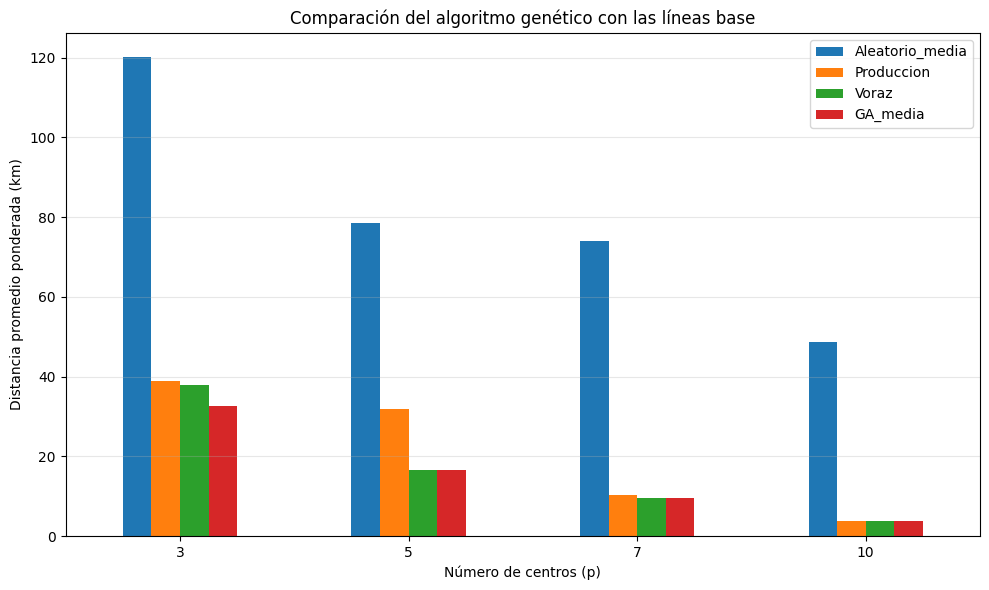

In [67]:
comparacion_ga_base.set_index("p")[
    [
        "Aleatorio_media",
        "Produccion",
        "Voraz",
        "GA_media"
    ]
].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.xlabel("Número de centros (p)")
plt.ylabel("Distancia promedio ponderada (km)")
plt.title(
    "Comparación del algoritmo genético con las líneas base"
)

plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

### 8.15 Interpretación de los resultados monoobjetivo

Los resultados muestran que el algoritmo genético obtuvo soluciones consistentemente mejores que la selección aleatoria para todos los valores de $p$. A medida que aumenta el número de centros de acopio, la distancia promedio ponderada disminuye de manera considerable.

Para $p=3$, el algoritmo genético alcanzó una distancia promedio ponderada de aproximadamente $32.56km$, mientras que la selección aleatoria obtuvo una media de $120.18km$. Esto representa una reducción aproximada del $72.91\%$.

Al incrementar el número de centros a $p=5$, el valor obtenido por el GA disminuyó a $16.62km$. Para $p=7$, la distancia se redujo a $9.64km$ y, finalmente, con $p=10$ se alcanzó un valor de aproximadamente $3.72km$.

El algoritmo genético también superó a la heurística basada únicamente en producción para todos los valores analizados. La diferencia fue especialmente importante para $p=3$ y $p=5$, donde considerar solamente los municipios con mayor producción no produjo una distribución espacial tan eficiente de los centros.

Al comparar el GA con la heurística voraz se observa un comportamiento diferente. Para $p=3$, el GA mejoró el valor de la heurística voraz, pasando de $38.02km$ a $32.56km$. Sin embargo, para $p=5$, $p=7$ y $p=10$, ambos métodos alcanzaron exactamente el mismo valor de la función objetivo.

Otro resultado relevante es que las 30 corridas del algoritmo genético produjeron el mismo valor para cada número de centros. Por esta razón, la media, mediana, mejor y peor solución coinciden, y la desviación estándar es igual a cero. Bajo la configuración experimental utilizada, esto indica un comportamiento altamente estable y una convergencia consistente hacia la misma calidad de solución.

Estos resultados muestran que el algoritmo genético aporta una mejora clara frente a estrategias simples, particularmente frente a la selección aleatoria y la selección basada exclusivamente en producción. No obstante, la heurística voraz resulta altamente competitiva para este problema, ya que iguala al GA en tres de los cuatro valores de $p$ analizados.

## 9. Analisis Estadistico

Para determinar si las diferencias observadas entre el algoritmo genético y la selección aleatoria son estadísticamente significativas, se utiliza la prueba no paramétrica de Wilcoxon para muestras pareadas.

La comparación se realiza utilizando las mismas 30 semillas en ambos métodos para cada valor de $p$. La hipótesis nula establece que no existe una diferencia sistemática entre los resultados obtenidos por ambos métodos.

Se considera un nivel de significancia de:

$$
\alpha = 0.05
$$

Por lo tanto, un valor $p < 0.05$ indica evidencia estadística suficiente para rechazar la hipótesis nula.

Además del valor $p$, se calcula la mejora porcentual del algoritmo genético respecto a la selección aleatoria.

### 9.1 Wilcoxon GA contra aleatorio

In [68]:
resultados_wilcoxon = []

for p in VALORES_P:

    # Resultados aleatorios ordenados por semilla
    aleatorio_p = (
        df_aleatorio[
            df_aleatorio["p"] == p
        ]
        .sort_values("semilla")["fitness"]
        .to_numpy()
    )

    # Resultados del GA ordenados por semilla
    ga_p = (
        df_ga[
            df_ga["p"] == p
        ]
        .sort_values("semilla")["fitness"]
        .to_numpy()
    )

    # Prueba de Wilcoxon pareada
    estadistico, valor_p = wilcoxon(
        aleatorio_p,
        ga_p,
        alternative="greater"
    )

    # Mejora porcentual respecto a la media aleatoria
    media_aleatoria = np.mean(aleatorio_p)
    media_ga = np.mean(ga_p)

    mejora = (
        (media_aleatoria - media_ga)
        / media_aleatoria
    ) * 100

    resultados_wilcoxon.append({
        "p": p,
        "estadistico_W": estadistico,
        "valor_p": valor_p,
        "media_aleatoria": media_aleatoria,
        "media_GA": media_ga,
        "mejora_porcentual": mejora
    })


df_wilcoxon = pd.DataFrame(
    resultados_wilcoxon
)

display(df_wilcoxon)

,p,estadistico_W,valor_p,media_aleatoria,media_GA,mejora_porcentual
0,3,465.0,9.313226e-10,120.178220,32.561412,72.905729
1,5,465.0,9.313226e-10,78.449014,16.621667,78.812140
2,7,465.0,9.313226e-10,73.971510,9.639805,86.968220
3,10,465.0,9.313226e-10,48.726742,3.721809,92.361876


In [69]:
df_wilcoxon_mostrar = df_wilcoxon.copy()

df_wilcoxon_mostrar["valor_p"] = (
    df_wilcoxon_mostrar["valor_p"]
    .map(lambda x: f"{x:.3e}")
)

df_wilcoxon_mostrar[
    "media_aleatoria"
] = df_wilcoxon_mostrar[
    "media_aleatoria"
].round(4)

df_wilcoxon_mostrar[
    "media_GA"
] = df_wilcoxon_mostrar[
    "media_GA"
].round(4)

df_wilcoxon_mostrar[
    "mejora_porcentual"
] = df_wilcoxon_mostrar[
    "mejora_porcentual"
].round(2)

display(df_wilcoxon_mostrar)

,p,estadistico_W,valor_p,media_aleatoria,media_GA,mejora_porcentual
0,3,465.0,9.313e-10,120.1782,32.5614,72.91
1,5,465.0,9.313e-10,78.4490,16.6217,78.81
2,7,465.0,9.313e-10,73.9715,9.6398,86.97
3,10,465.0,9.313e-10,48.7267,3.7218,92.36


## 9.2 Interpretacion

In [70]:
ALPHA = 0.05

for _, fila in df_wilcoxon.iterrows():

    p = int(fila["p"])
    valor_p = fila["valor_p"]

    if valor_p < ALPHA:
        resultado = "diferencia estadísticamente significativa"
    else:
        resultado = "diferencia no estadísticamente significativa"

    print(
        f"p={p}: valor-p={valor_p:.3e} -> {resultado}"
    )
print(df_wilcoxon)

p=3: valor-p=9.313e-10 -> diferencia estadísticamente significativa
p=5: valor-p=9.313e-10 -> diferencia estadísticamente significativa
p=7: valor-p=9.313e-10 -> diferencia estadísticamente significativa
p=10: valor-p=9.313e-10 -> diferencia estadísticamente significativa
    p  estadistico_W       valor_p  media_aleatoria   media_GA  mejora_porcentual
0   3          465.0  9.313226e-10       120.178220  32.561412          72.905729
1   5          465.0  9.313226e-10        78.449014  16.621667          78.812140
2   7          465.0  9.313226e-10        73.971510   9.639805          86.968220
3  10          465.0  9.313226e-10        48.726742   3.721809          92.361876


La prueba de Wilcoxon mostró diferencias estadísticamente significativas entre el algoritmo genético y la selección aleatoria para todos los valores del número de centros analizados.

En los cuatro casos se obtuvo un valor $p$ de aproximadamente:

$
9.31\times10^{-10}
$

Este valor es considerablemente menor que el nivel de significancia establecido, $\alpha=0.05$. Por lo tanto, se rechaza la hipótesis nula y se encuentra evidencia estadística de que la distancia promedio ponderada obtenida mediante el algoritmo genético es menor que la obtenida mediante selección aleatoria.

La magnitud de la mejora también aumenta conforme se incrementa el número de centros. Para $p=3$, el algoritmo genético redujo la distancia promedio ponderada aproximadamente un $72.91\%$ respecto a la media de la selección aleatoria. Para $p=5$, la reducción fue del $78.81\%$, mientras que para $p=7$ alcanzó el $86.97\%$. Finalmente, para $p=10$, se obtuvo una mejora del $92.36\%$.

En conjunto, los resultados estadísticos indican que la ventaja observada del algoritmo genético frente a la selección aleatoria no corresponde únicamente a variaciones producidas por las diferentes corridas, sino que existe una diferencia sistemática entre ambos métodos.

## 10. Optimización multiobjetivo con dos objetivos

La formulación monoobjetivo prioriza la eficiencia global de la red de centros de acopio mediante la minimización de la distancia promedio ponderada por producción. Sin embargo, una solución eficiente en promedio puede ocasionar que algunos municipios se encuentren considerablemente alejados de su centro de atención más cercano.

Para incorporar un criterio de cobertura territorial se plantea una segunda formulación con dos objetivos.

El primer objetivo corresponde a la distancia promedio ponderada por producción:

$$
f_1(x)=
\frac{\sum_{i=1}^{43}P_i d_i^{\min}}
{\sum_{i=1}^{43}P_i}
$$

El segundo objetivo corresponde a la mayor distancia existente entre un municipio y su centro de acopio asignado:

$$
f_2(x)=
\max_i d_i^{\min}
$$

Por lo tanto, se busca simultáneamente:

$$
\min (f_1(x), f_2(x))
$$

manteniendo la restricción:

$$
\sum_{j=1}^{43}x_j=p
$$

para:

$$
p\in\{3,5,7,10\}
$$

Debido a que ambos objetivos pueden entrar en conflicto, el problema se resuelve mediante NSGA-II. El resultado consiste en un conjunto de soluciones no dominadas que representan diferentes compromisos entre eficiencia promedio y cobertura territorial.

### 10.1 Funcion para calcular los dos objetivos

In [71]:
def evaluar_dos_objetivos(x):
    """
    Calcula los dos objetivos del problema multiobjetivo.

    f1: distancia promedio ponderada por producción.
    f2: distancia máxima de atención.
    """

    x = np.asarray(x, dtype=int)

    centros = np.where(x == 1)[0]

    if len(centros) == 0:
        return np.inf, np.inf

    # Distancia al centro seleccionado más cercano
    distancias_minimas = np.min(
        D[:, centros],
        axis=1
    )

    # Objetivo 1: distancia promedio ponderada
    f1 = np.sum(
        P * distancias_minimas
    ) / PRODUCCION_TOTAL

    # Objetivo 2: distancia máxima
    f2 = np.max(
        distancias_minimas
    )

    return f1, f2

### Prueba


In [72]:
f1_prueba, f2_prueba = evaluar_dos_objetivos(
    mejores_x_ga[3]
)

print(
    f"f1 - Distancia promedio ponderada: "
    f"{f1_prueba:.4f} km"
)

print(
    f"f2 - Distancia máxima de atención: "
    f"{f2_prueba:.4f} km"
)

f1 - Distancia promedio ponderada: 32.5614 km
f2 - Distancia máxima de atención: 218.7570 km


### 10.2 Definir el problema en PYMOO

In [73]:
class ProblemaCentrosMultiobjetivo(ElementwiseProblem):

    def __init__(self, p):

        self.p = p

        super().__init__(
            n_var=N,
            n_obj=2,
            n_ieq_constr=0,
            xl=0,
            xu=1
        )

    def _evaluate(self, x, out, *args, **kwargs):

        x = np.asarray(x).astype(int)

        f1, f2 = evaluar_dos_objetivos(x)

        out["F"] = [
            f1,
            f2
        ]

### 10.3importamos NSGGA-II

In [74]:
from pymoo.algorithms.moo.nsga2 import NSGA2

### 10.4 Configurar NSGA-II

In [75]:
POBLACION_NSGA2 = 100
GENERACIONES_NSGA2 = 200

PROB_CRUCE_NSGA2 = 0.90
PROB_MUTACION_NSGA2 = 1.0 / N

SEMILLA_NSGA2 = 42

print("Población:", POBLACION_NSGA2)
print("Generaciones:", GENERACIONES_NSGA2)
print("Probabilidad de cruce:", PROB_CRUCE_NSGA2)
print("Probabilidad de mutación:", PROB_MUTACION_NSGA2)
print("Semilla:", SEMILLA_NSGA2)

Población: 100
Generaciones: 200
Probabilidad de cruce: 0.9
Probabilidad de mutación: 0.023255813953488372
Semilla: 42


### 10.5 Función para ejecutar NSGA-II

In [76]:
def ejecutar_nsga2(p, semilla=SEMILLA_NSGA2):

    problema = ProblemaCentrosMultiobjetivo(p)

    algoritmo = NSGA2(
        pop_size=POBLACION_NSGA2,

        sampling=BinaryRandomSampling(),

        crossover=TwoPointCrossover(
            prob=PROB_CRUCE_NSGA2
        ),

        mutation=BitflipMutation(
            prob=PROB_MUTACION_NSGA2
        ),

        repair=ReparacionCardinalidad(p),

        eliminate_duplicates=True
    )

    resultado = minimize(
        problema,
        algoritmo,
        termination=(
            "n_gen",
            GENERACIONES_NSGA2
        ),
        seed=semilla,
        verbose=False
    )

    return resultado

### 10.6 Primera ejecución para p=3

In [77]:
resultado_nsga2_p3 = ejecutar_nsga2(
    p=3
)

X_p3 = np.asarray(
    resultado_nsga2_p3.X
).astype(int)

F_p3 = np.asarray(
    resultado_nsga2_p3.F
)

print(
    "Número de soluciones no dominadas:",
    len(F_p3)
)

print(
    "Dimensiones de F:",
    F_p3.shape
)

print(
    "Dimensiones de X:",
    X_p3.shape
)

Número de soluciones no dominadas: 11
Dimensiones de F: (11, 2)
Dimensiones de X: (11, 43)


### 10.7 Visualizar el primer Frente de Pareto

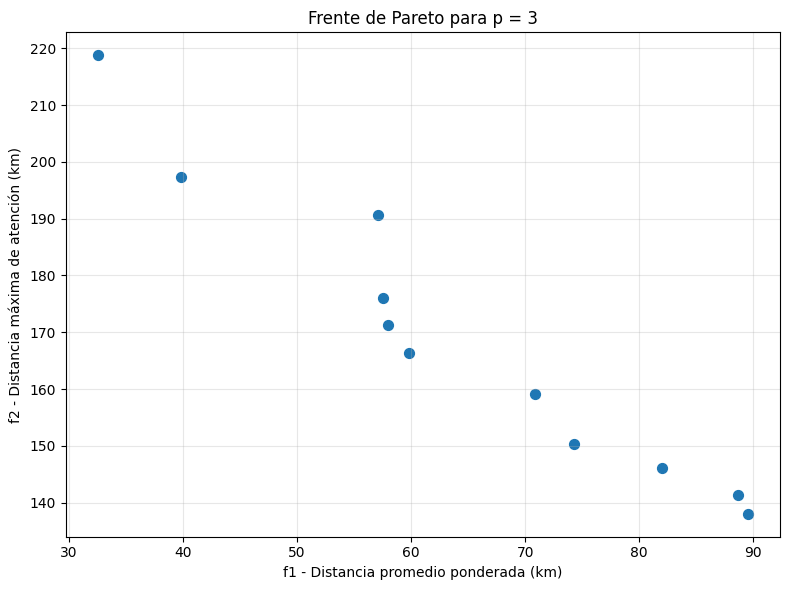

In [78]:
plt.figure(figsize=(8, 6))

plt.scatter(
    F_p3[:, 0],
    F_p3[:, 1],
    s=50
)

plt.xlabel(
    "f1 - Distancia promedio ponderada (km)"
)

plt.ylabel(
    "f2 - Distancia máxima de atención (km)"
)

plt.title(
    "Frente de Pareto para p = 3"
)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

El Frente de Pareto muestra un intercambio claro entre los dos objetivos considerados. Las soluciones con menor distancia promedio ponderada $f_1$ presentan una distancia máxima de atención $f_2$ relativamente elevada. Por el contrario, al reducir la distancia máxima de atención se incrementa la distancia promedio ponderada.

Esto indica que no existe una única solución óptima para ambos objetivos simultáneamente. La selección final depende de la prioridad asignada a la eficiencia logística global o a una mayor equidad territorial en la cobertura de los municipios.

### 10.8 Ejecucion de NSGA-II para todo los valores de $p$

In [79]:
resultados_nsga2 = {}

for p in VALORES_P:

    print(f"Ejecutando NSGA-II para p = {p}")

    resultado = ejecutar_nsga2(
        p=p,
        semilla=SEMILLA_NSGA2
    )

    X = np.asarray(
        resultado.X
    ).astype(int)

    F = np.asarray(
        resultado.F
    )

    resultados_nsga2[p] = {
        "X": X,
        "F": F
    }

    print(
        f"  Soluciones no dominadas: {len(F)}"
    )

Ejecutando NSGA-II para p = 3
  Soluciones no dominadas: 11
Ejecutando NSGA-II para p = 5
  Soluciones no dominadas: 10
Ejecutando NSGA-II para p = 7
  Soluciones no dominadas: 13
Ejecutando NSGA-II para p = 10
  Soluciones no dominadas: 19


### 10.9 IDENTIFICAR SOLUCIONES REPRESENTATIVAS


In [80]:
resumen_pareto = []

for p in VALORES_P:

    X = resultados_nsga2[p]["X"]
    F = resultados_nsga2[p]["F"]

    # Menor f1
    idx_f1 = np.argmin(F[:, 0])

    # Menor f2
    idx_f2 = np.argmin(F[:, 1])

    # Normalización para calcular una solución de compromiso
    f_min = F.min(axis=0)
    f_max = F.max(axis=0)

    F_norm = (
        (F - f_min)
        / (f_max - f_min + 1e-12)
    )

    # Distancia al punto ideal (0,0)
    distancia_ideal = np.sqrt(
        np.sum(F_norm**2, axis=1)
    )

    idx_compromiso = np.argmin(
        distancia_ideal
    )

    resumen_pareto.append({
        "p": p,
        "n_soluciones": len(F),

        "f1_min": F[idx_f1, 0],
        "f2_en_f1_min": F[idx_f1, 1],

        "f1_en_f2_min": F[idx_f2, 0],
        "f2_min": F[idx_f2, 1],

        "f1_compromiso": F[idx_compromiso, 0],
        "f2_compromiso": F[idx_compromiso, 1]
    })


df_resumen_pareto = pd.DataFrame(
    resumen_pareto
)

display(
    df_resumen_pareto.round(4)
)

,p,n_soluciones,f1_min,f2_en_f1_min,f1_en_f2_min,f2_min,f1_compromiso,f2_compromiso
0,3,11,32.5614,218.7570,89.5045,138.0459,59.7711,166.3944
1,5,10,16.6217,218.7570,29.7023,106.0083,19.5093,159.1214
2,7,13,9.6398,218.7570,39.7127,81.4828,13.7626,106.0083
3,10,19,3.7218,197.3279,32.0021,59.6012,9.1996,91.8203


### 10.10 Guardar Soluciones Representativas

In [81]:
soluciones_representativas = {}

for p in VALORES_P:

    X = resultados_nsga2[p]["X"]
    F = resultados_nsga2[p]["F"]

    idx_f1 = np.argmin(F[:, 0])
    idx_f2 = np.argmin(F[:, 1])

    f_min = F.min(axis=0)
    f_max = F.max(axis=0)

    F_norm = (
        (F - f_min)
        / (f_max - f_min + 1e-12)
    )

    distancia_ideal = np.sqrt(
        np.sum(F_norm**2, axis=1)
    )

    idx_compromiso = np.argmin(
        distancia_ideal
    )

    soluciones_representativas[p] = {
        "menor_f1": X[idx_f1],
        "menor_f2": X[idx_f2],
        "compromiso": X[idx_compromiso]
    }


### 10.11 FRENTES DE PARETO



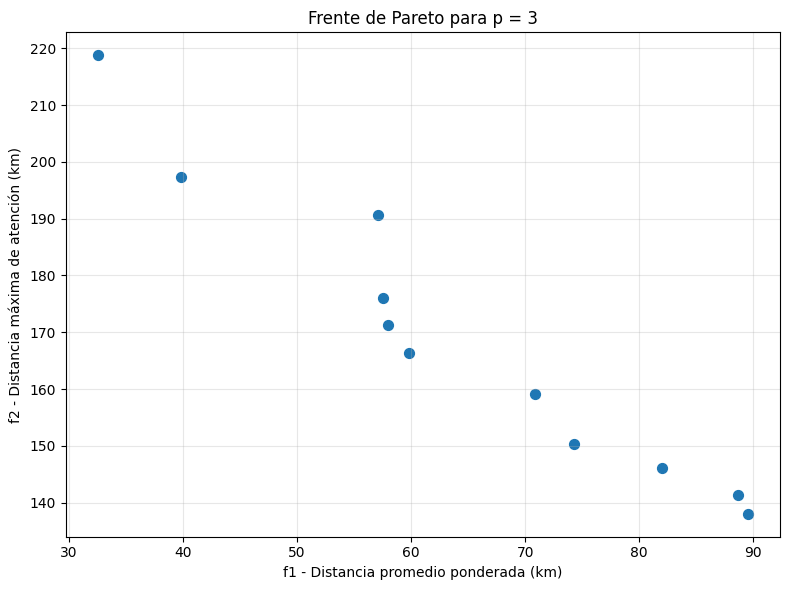

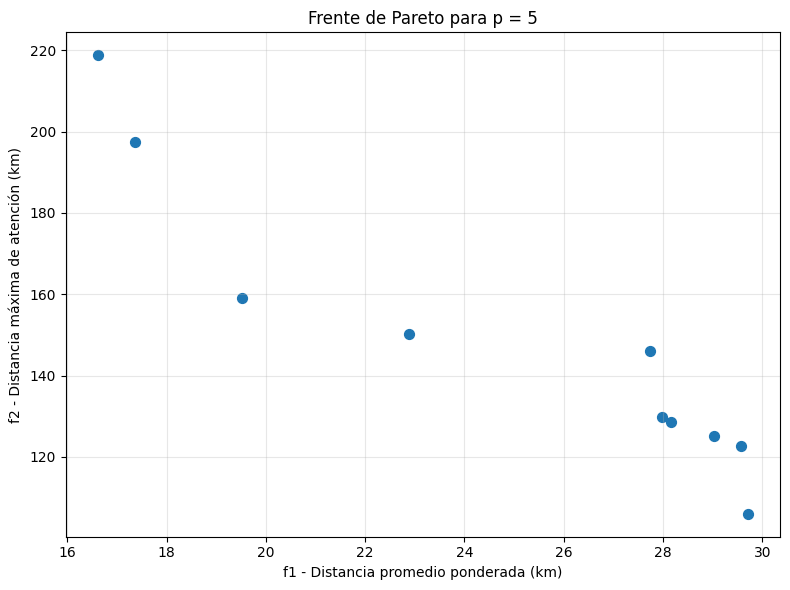

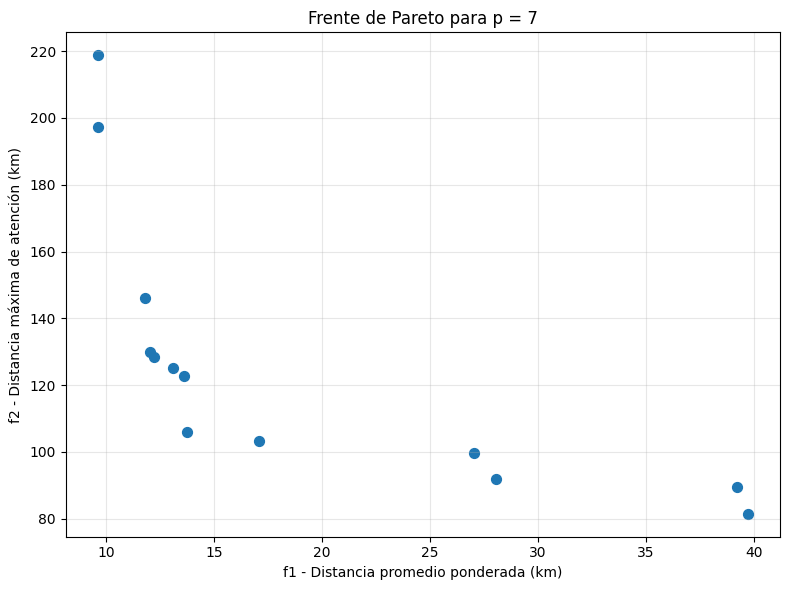

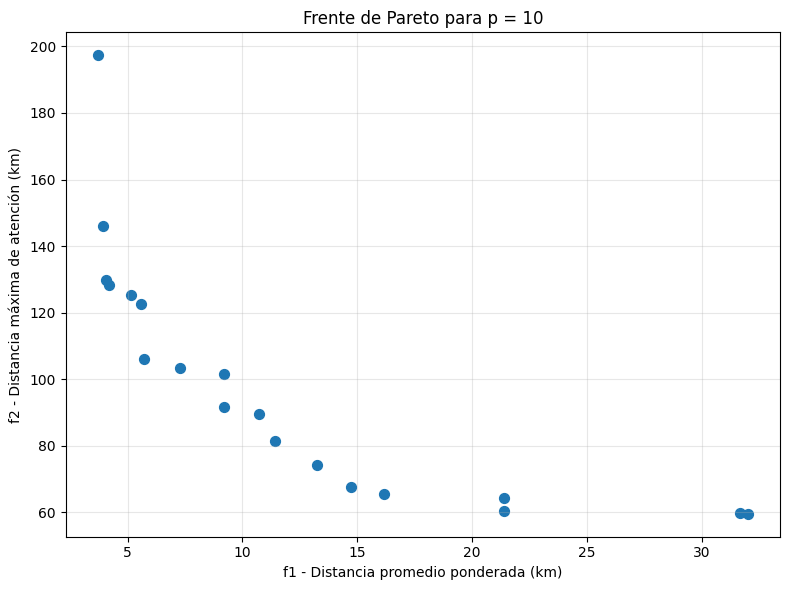

In [82]:
for p in VALORES_P:

    F = resultados_nsga2[p]["F"]

    plt.figure(figsize=(8, 6))

    plt.scatter(
        F[:, 0],
        F[:, 1],
        s=50
    )

    plt.xlabel(
        "f1 - Distancia promedio ponderada (km)"
    )

    plt.ylabel(
        "f2 - Distancia máxima de atención (km)"
    )

    plt.title(
        f"Frente de Pareto para p = {p}"
    )

    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

In [83]:
print(df_resumen_pareto)

    p  n_soluciones     f1_min  f2_en_f1_min  f1_en_f2_min      f2_min  f1_compromiso  f2_compromiso
0   3            11  32.561412    218.757001     89.504462  138.045942      59.771136     166.394431
1   5            10  16.621667    218.757001     29.702325  106.008269      19.509265     159.121441
2   7            13   9.639805    218.757001     39.712705   81.482774      13.762580     106.008269
3  10            19   3.721809    197.327862     32.002106   59.601168       9.199574      91.820321


### 10.12 Interpretación de los resultados multiobjetivo

Los resultados obtenidos mediante NSGA-II muestran un compromiso claro entre la distancia promedio ponderada $f_1$ y la distancia máxima de atención $f_2$.

Para $p=3$, la solución que minimiza $f_1$ alcanza aproximadamente $32.56$ km, pero presenta una distancia máxima de atención de $218.76 km$. En el extremo opuesto, la solución que minimiza $f_2$ reduce la distancia máxima a $138.05 km$, aunque la distancia promedio ponderada aumenta hasta $89.50 km$. La solución de compromiso presenta valores intermedios de aproximadamente $59.77 km$ para $f_1$ y $166.39 km$ para $f_2$.

Para $p=5$, el valor mínimo de $f_1$ disminuye a $16.62 km$, mientras que la mejor cobertura territorial alcanza un $f_2$ de $106.01 km$. La solución de compromiso se encuentra en aproximadamente $19.51 km$ para $f_1$ y $159.12$ km para $f_2$.

Con $p=7$, el valor mínimo de $f_1$ se reduce a $9.64 km$ y el valor mínimo de $f_2$ a $81.48 km$. La solución de compromiso alcanza aproximadamente $13.76 km$ de distancia promedio ponderada y $106.01 km$ de distancia máxima.

Finalmente, para $p=10$, el mejor valor de $f_1$ es de $3.72 km$ y la menor distancia máxima de atención es de $59.60 km$. La solución de compromiso presenta valores de aproximadamente $9.20 km$ para $f_1$ y $91.82 km$ para $f_2$.

En general, al incrementar el número de centros de acopio, los frentes de Pareto se desplazan hacia valores menores de ambos objetivos. Esto indica que una mayor cantidad de instalaciones permite mejorar simultáneamente la eficiencia promedio y la cobertura territorial.

Sin embargo, dentro de cada valor de $p$ permanece un intercambio entre ambos objetivos. Las soluciones que priorizan la distancia promedio ponderada tienden a aceptar una mayor distancia máxima de atención, mientras que las soluciones que buscan una cobertura territorial más uniforme sacrifican parcialmente la eficiencia promedio.

Este comportamiento confirma que el problema multiobjetivo no posee una única solución óptima, sino un conjunto de alternativas no dominadas entre las cuales debe seleccionarse de acuerdo con las prioridades logísticas y territoriales.

| $$p$$ | Sol. no dominadas | $$f_1$$ mín. | $$f_2$$ asociado | $$f_2$$ mín. | $$f_1$$ asociado | Compromiso $$f_1$$ | Compromiso $$f_2$$ |
| --: | ----------------: | ---------: | -------------: | ---------: | -------------: | ---------------: | ---------------: |
|   3 |                11 |      32.56 |         218.76 |     138.05 |          89.50 |            59.77 |           166.39 |
|   5 |                10 |      16.62 |         218.76 |     106.01 |          29.70 |            19.51 |           159.12 |
|   7 |                13 |       9.64 |         218.76 |      81.48 |          39.71 |            13.76 |           106.01 |
|  10 |                19 |       3.72 |         197.33 |      59.60 |          32.00 |             9.20 |            91.82 |

## 11. Optimización multiobjetivo con tres objetivos

En la tercera formulación se permite que el algoritmo determine también el número de centros de acopio a instalar.

Los objetivos considerados son:

* $$
f_1(x)=
\frac{\sum_{i=1}^{43}P_i d_i^{\min}}
{\sum_{i=1}^{43}P_i}
$$

* $$
f_2(x)=
\max_i d_i^{\min}
$$

* $$
f_3(x)=
\sum_{j=1}^{43}x_j
$$

La restricción sobre el número de centros es:

$$
3 \leq \sum_{j=1}^{43}x_j \leq 10
$$

De esta manera, el problema busca simultáneamente minimizar la distancia promedio ponderada, la distancia máxima de atención y la cantidad de infraestructura instalada.

El resultado permitirá analizar cuántos centros representan un compromiso razonable entre eficiencia logística, cobertura territorial y número de instalaciones.

### 11.1 REPARACIÓN PARA 3 A 10 CENTROS


In [84]:
class ReparacionRangoCentros(Repair):

    def __init__(self, minimo=3, maximo=10):
        super().__init__()

        self.minimo = minimo
        self.maximo = maximo

    def _do(self, problem, X, **kwargs):

        X = X.astype(bool)

        for i in range(len(X)):

            seleccionados = np.where(X[i])[0]
            no_seleccionados = np.where(~X[i])[0]

            cantidad = len(seleccionados)

            # Si hay menos del mínimo
            if cantidad < self.minimo:

                agregar = np.random.choice(
                    no_seleccionados,
                    size=self.minimo - cantidad,
                    replace=False
                )

                X[i, agregar] = True

            # Si hay más del máximo
            elif cantidad > self.maximo:

                eliminar = np.random.choice(
                    seleccionados,
                    size=cantidad - self.maximo,
                    replace=False
                )

                X[i, eliminar] = False

        return X

### 11.2 Definir el problema de tres objetivos

In [85]:
class ProblemaCentrosTresObjetivos(ElementwiseProblem):

    def __init__(self):

        super().__init__(
            n_var=N,
            n_obj=3,
            n_ieq_constr=0,
            xl=0,
            xu=1
        )

    def _evaluate(self, x, out, *args, **kwargs):

        x = np.asarray(x).astype(int)

        centros = np.where(x == 1)[0]

        distancias_minimas = np.min(
            D[:, centros],
            axis=1
        )

        # Objetivo 1
        f1 = np.sum(
            P * distancias_minimas
        ) / PRODUCCION_TOTAL

        # Objetivo 2
        f2 = np.max(
            distancias_minimas
        )

        # Objetivo 3
        f3 = np.sum(x)

        out["F"] = [
            f1,
            f2,
            f3
        ]

### 11.3 Ejecutar NSGA-II con tres objetivos

In [86]:
# ============================================================
# NSGA-II CON TRES OBJETIVOS
# ============================================================

problema_3obj = ProblemaCentrosTresObjetivos()

algoritmo_3obj = NSGA2(
    pop_size=150,

    sampling=BinaryRandomSampling(),

    crossover=TwoPointCrossover(
        prob=0.90
    ),

    mutation=BitflipMutation(
        prob=1.0 / N
    ),

    repair=ReparacionRangoCentros(
        minimo=3,
        maximo=10
    ),

    eliminate_duplicates=True
)

resultado_3obj = minimize(
    problema_3obj,
    algoritmo_3obj,
    termination=(
        "n_gen",
        300
    ),
    seed=42,
    verbose=False
)

### 11.4 Revisar resultados

In [87]:
X_3obj = np.asarray(
    resultado_3obj.X
).astype(int)

F_3obj = np.asarray(
    resultado_3obj.F
)

print(
    "Número de soluciones no dominadas:",
    len(F_3obj)
)

print(
    "Dimensiones de objetivos:",
    F_3obj.shape
)

print(
    "Número mínimo de centros encontrado:",
    int(F_3obj[:, 2].min())
)

print(
    "Número máximo de centros encontrado:",
    int(F_3obj[:, 2].max())
)

Número de soluciones no dominadas: 98
Dimensiones de objetivos: (98, 3)
Número mínimo de centros encontrado: 3
Número máximo de centros encontrado: 10


### 11.5 Convertir resultados a DataFrame

In [88]:
df_3obj = pd.DataFrame({
    "f1_distancia_promedio": F_3obj[:, 0],
    "f2_distancia_maxima": F_3obj[:, 1],
    "f3_centros": F_3obj[:, 2].astype(int)
})

display(
    df_3obj.sort_values(
        ["f3_centros", "f1_distancia_promedio"]
    )
)

,f1_distancia_promedio,f2_distancia_maxima,f3_centros
7,32.561412,218.757001,3
4,39.789814,197.327862,3
0,57.082257,190.624696,3
12,57.535605,176.097157,3
3,57.960263,171.210441,3
...,...,...,...
85,12.967969,80.642886,10
75,13.246387,74.208543,10
78,15.200193,69.722158,10
73,22.497550,64.340019,10


### 11.6 Resumen según número de centros

In [89]:
resumen_3obj = (
    df_3obj
    .groupby("f3_centros")
    .agg(
        numero_soluciones=(
            "f1_distancia_promedio",
            "count"
        ),

        mejor_f1=(
            "f1_distancia_promedio",
            "min"
        ),

        mejor_f2=(
            "f2_distancia_maxima",
            "min"
        ),

        media_f1=(
            "f1_distancia_promedio",
            "mean"
        ),

        media_f2=(
            "f2_distancia_maxima",
            "mean"
        )
    )
    .reset_index()
)

display(
    resumen_3obj.round(4)
)

,f3_centros,numero_soluciones,mejor_f1,mejor_f2,media_f1,media_f2
0,3,10,32.5614,138.0459,62.1301,171.4007
1,4,10,20.4873,125.2327,37.9853,155.8812
2,5,10,16.6217,106.0083,24.8690,148.3839
3,6,13,12.7804,95.2291,22.6398,132.9946
4,7,12,9.6398,81.4828,18.3723,128.3816
5,8,12,6.5049,80.6429,15.4543,116.8721
6,9,15,4.5419,64.3055,13.9184,107.3801
7,10,16,3.7218,64.3055,10.0065,104.6901


### 11.7 Interpretación de la formulación con tres objetivos

Los resultados muestran que el incremento en el número de centros de acopio mejora de forma progresiva tanto la distancia promedio ponderada $f_1$ como la distancia máxima de atención $f_2$.

Con $p=3$ centros, el mejor valor de $f_1$ es de aproximadamente $32.56$ km, mientras que el mejor valor de $f_2$ es de $138.05$ km. Al incrementar gradualmente el número de instalaciones, ambos objetivos disminuyen.

Para $p=5$, el mejor valor de $f_1$ se reduce a $16.62$ km y el mejor valor de $f_2$ a $106.01$ km. Con $p=7$, estos valores disminuyen a aproximadamente $9.64$ km y $81.48$ km, respectivamente.

A partir de $p=7$, continuar incrementando la infraestructura sigue produciendo mejoras, aunque no siempre de manera uniforme. Por ejemplo, al pasar de 7 a 8 centros, el mejor valor de $f_1$ mejora de $9.64$ km a $6.50$ km, mientras que $f_2$ prácticamente permanece sin cambios, pasando de $81.48$ km a $80.64$ km.

El incremento a $p=9$ produce una mejora más notable en ambos objetivos, alcanzando aproximadamente $4.54$ km para $f_1$ y $64.31$ km para $f_2$. Finalmente, con $p=10$ se obtiene el menor valor de $f_1$, de aproximadamente $3.72$ km, mientras que el mejor valor de $f_2$ permanece en $64.31$ km.

Por lo tanto, agregar un décimo centro continúa mejorando la eficiencia promedio, pero no produce una reducción adicional en la mejor distancia máxima de atención encontrada. Este comportamiento indica que la mejora obtenida al incrementar el número de instalaciones no es constante.

En particular, la ausencia de mejora en $f_2$ al pasar de $p=9$ a $p=10$ sugiere la presencia de rendimientos decrecientes desde la perspectiva de cobertura territorial.

Por lo tanto, si se busca un equilibrio entre desempeño logístico y cantidad de infraestructura, las soluciones comprendidas entre $p=7$ y $p=9$ representan alternativas de interés. La elección final dependerá del costo asociado con instalar centros adicionales y de la importancia asignada a los tres objetivos:

$$
\min f_1(x), \qquad
\min f_2(x), \qquad
\min f_3(x)
$$

donde $f_1$ representa la distancia promedio ponderada, $f_2$ la distancia máxima de atención y $f_3$ el número de centros instalados.

### 11.8 Visualización de las soluciones con tres objetivos

Para analizar simultáneamente los tres objetivos, se representan las soluciones no dominadas obtenidas mediante NSGA-II utilizando $f_1$ y $f_2$ como ejes de la gráfica, mientras que el número de centros $f_3$ se representa mediante una escala de color.

Esta representación permite observar cómo cambia el compromiso entre la distancia promedio ponderada y la distancia máxima de atención conforme aumenta el número de centros instalados.

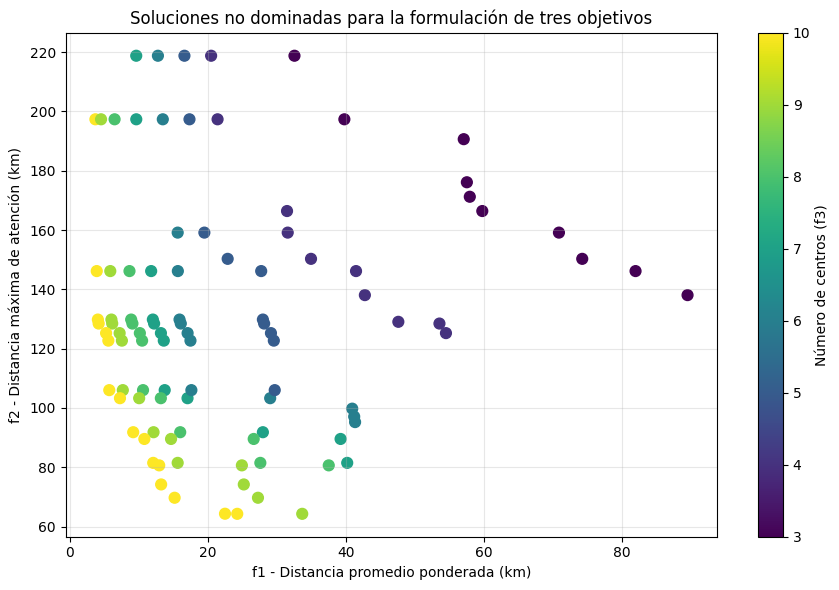

In [90]:
plt.figure(figsize=(9, 6))

scatter = plt.scatter(
    F_3obj[:, 0],
    F_3obj[:, 1],
    c=F_3obj[:, 2],
    s=60,
    cmap="viridis"
)

plt.xlabel(
    "f1 - Distancia promedio ponderada (km)"
)

plt.ylabel(
    "f2 - Distancia máxima de atención (km)"
)

plt.title(
    "Soluciones no dominadas para la formulación de tres objetivos"
)

cbar = plt.colorbar(scatter)
cbar.set_label("Número de centros (f3)")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 11.9 Efecto del número de centros sobre los objetivos

Para observar con mayor claridad el efecto de incrementar el número de instalaciones, se comparan los mejores valores encontrados para $f_1$ y $f_2$ en función del número de centros.

Debido a que ambos objetivos presentan escalas diferentes, se muestran en gráficas independientes para facilitar su interpretación.

**$f_1:$**

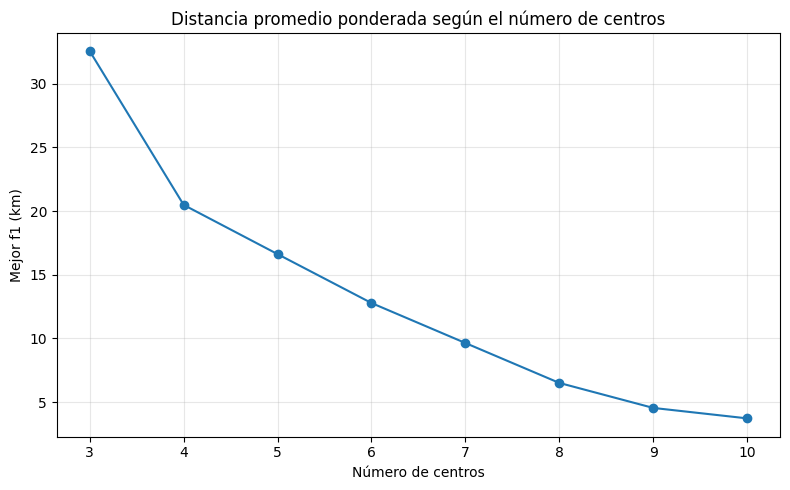

In [91]:
plt.figure(figsize=(8, 5))

plt.plot(
    resumen_3obj["f3_centros"],
    resumen_3obj["mejor_f1"],
    marker="o"
)

plt.xlabel("Número de centros")
plt.ylabel("Mejor f1 (km)")

plt.title(
    "Distancia promedio ponderada según el número de centros"
)

plt.xticks(
    resumen_3obj["f3_centros"]
)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

**$f_2:$**

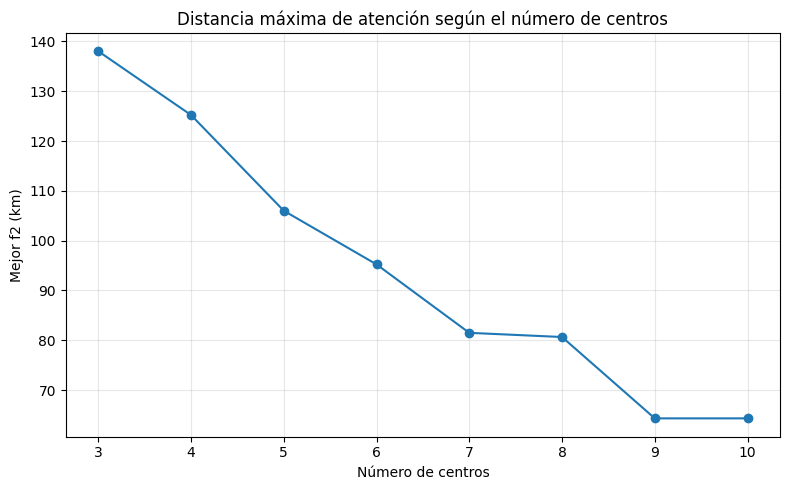

In [92]:
plt.figure(figsize=(8, 5))

plt.plot(
    resumen_3obj["f3_centros"],
    resumen_3obj["mejor_f2"],
    marker="o"
)

plt.xlabel("Número de centros")
plt.ylabel("Mejor f2 (km)")

plt.title(
    "Distancia máxima de atención según el número de centros"
)

plt.xticks(
    resumen_3obj["f3_centros"]
)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 11.10 Análisis del efecto del número de centros

Las gráficas muestran que incrementar el número de centros de acopio produce una reducción general de los dos objetivos analizados. Sin embargo, la magnitud de la mejora obtenida mediante cada centro adicional no es constante.

En el caso de la distancia promedio ponderada $f_1$, se observa una disminución continua desde $32.56$ km con $p=3$ hasta $3.72$ km con $p=10$. La reducción más pronunciada ocurre al pasar de 3 a 4 centros, mientras que conforme aumenta el número de instalaciones las mejoras adicionales son progresivamente menores.

Para la distancia máxima de atención $f_2$ también se observa una tendencia descendente, pasando de $138.05$ km con 3 centros a $64.31$ km con 9 centros. Sin embargo, existen regiones donde agregar infraestructura produce una mejora limitada. Entre $p=7$ y $p=8$, la distancia máxima disminuye únicamente de $81.48$ km a $80.64$ km.

Un comportamiento aún más evidente aparece entre $p=9$ y $p=10$, donde el mejor valor de $f_2$ permanece en aproximadamente $64.31$ km. Esto significa que, dentro de las soluciones encontradas, instalar un décimo centro mejora la distancia promedio ponderada $f_1$, pero no proporciona una reducción adicional de la mejor distancia máxima de atención.

Por lo tanto, los resultados muestran la existencia de rendimientos decrecientes al incrementar el número de centros. Desde una perspectiva de cobertura territorial, $p=9$ resulta particularmente relevante, debido a que alcanza el mismo mejor valor de $f_2$ que $p=10$ utilizando una instalación menos. No obstante, si se prioriza exclusivamente la reducción de $f_1$, la configuración con 10 centros continúa ofreciendo el mejor desempeño.

## 12. Guardado de resultados

Para facilitar la reproducibilidad del proyecto, los principales resultados experimentales se almacenan automáticamente en archivos CSV.

Se utilizan dos directorios principales:

- `results/`: almacenar los resultados numéricos obtenidos durante los experimentos.
- `figures/`: almacenar las figuras generadas para el análisis y posterior elaboración del artículo.

De esta manera, los resultados pueden consultarse sin necesidad de ejecutar nuevamente todos los algoritmos evolutivos.

### 12.1 Crear Carpetas

In [93]:
import os

RUTA_RESULTADOS = "results"
RUTA_FIGURAS = "figures"

os.makedirs(
    RUTA_RESULTADOS,
    exist_ok=True
)

os.makedirs(
    RUTA_FIGURAS,
    exist_ok=True
)

print("Carpetas preparadas correctamente:")
print(f"- {RUTA_RESULTADOS}/")
print(f"- {RUTA_FIGURAS}/")

Carpetas preparadas correctamente:
- results/
- figures/


### 12.2 Guardar resultados de las líneas base

In [94]:
df_aleatorio.to_csv(
    os.path.join(
        RUTA_RESULTADOS,
        "baseline_aleatorio.csv"
    ),
    index=False
)

resumen_aleatorio.to_csv(
    os.path.join(
        RUTA_RESULTADOS,
        "resumen_baseline_aleatorio.csv"
    ),
    index=False
)

df_produccion.to_csv(
    os.path.join(
        RUTA_RESULTADOS,
        "baseline_produccion.csv"
    ),
    index=False
)

df_voraz.to_csv(
    os.path.join(
        RUTA_RESULTADOS,
        "baseline_voraz.csv"
    ),
    index=False
)

### 12.3 Guardar resultados del algoritmo genético

In [95]:
df_ga.to_csv(
    os.path.join(
        RUTA_RESULTADOS,
        "resultados_ga.csv"
    ),
    index=False
)

resumen_ga.to_csv(
    os.path.join(
        RUTA_RESULTADOS,
        "resumen_ga.csv"
    ),
    index=False
)

mejores_ga.to_csv(
    os.path.join(
        RUTA_RESULTADOS,
        "mejores_soluciones_ga.csv"
    ),
    index=False
)

comparacion_ga_base.to_csv(
    os.path.join(
        RUTA_RESULTADOS,
        "comparacion_ga_baselines.csv"
    ),
    index=False
)

### 12.4 Guardar análisis estadístico

In [96]:
df_wilcoxon.to_csv(
    os.path.join(
        RUTA_RESULTADOS,
        "wilcoxon_ga_vs_aleatorio.csv"
    ),
    index=False
)

### 12.5 Guardar los frentes de Pareto de dos objetivos

In [97]:
for p in VALORES_P:

    F = resultados_nsga2[p]["F"]
    X = resultados_nsga2[p]["X"]

    filas = []

    for i in range(len(F)):

        centros = obtener_centros(
            X[i]
        )["municipio"].tolist()

        filas.append({
            "f1_distancia_promedio": F[i, 0],
            "f2_distancia_maxima": F[i, 1],
            "centros": ", ".join(centros)
        })

    df_pareto = pd.DataFrame(filas)

    df_pareto.to_csv(
        os.path.join(
            RUTA_RESULTADOS,
            f"pareto_2obj_p{p}.csv"
        ),
        index=False
    )

In [98]:
df_resumen_pareto.to_csv(
    os.path.join(
        RUTA_RESULTADOS,
        "resumen_pareto_2obj.csv"
    ),
    index=False
)

### 12.6 Guardar resultados de tres objetivos

In [99]:
filas_3obj = []

for i in range(len(F_3obj)):

    centros = obtener_centros(
        X_3obj[i]
    )["municipio"].tolist()

    filas_3obj.append({
        "f1_distancia_promedio": F_3obj[i, 0],
        "f2_distancia_maxima": F_3obj[i, 1],
        "f3_numero_centros": int(F_3obj[i, 2]),
        "centros": ", ".join(centros)
    })


df_resultados_3obj = pd.DataFrame(
    filas_3obj
)

df_resultados_3obj.to_csv(
    os.path.join(
        RUTA_RESULTADOS,
        "pareto_3objetivos.csv"
    ),
    index=False
)

resumen_3obj.to_csv(
    os.path.join(
        RUTA_RESULTADOS,
        "resumen_3objetivos.csv"
    ),
    index=False
)

### 12.7 Verificar qué archivos se generaron

In [100]:
for archivo in sorted(
    os.listdir(RUTA_RESULTADOS)
):
    print(archivo)

baseline_aleatorio.csv
baseline_produccion.csv
baseline_voraz.csv
comparacion_ga_baselines.csv
mejores_soluciones_ga.csv
pareto_2obj_p10.csv
pareto_2obj_p3.csv
pareto_2obj_p5.csv
pareto_2obj_p7.csv
pareto_3objetivos.csv
resultados_ga.csv
resumen_3objetivos.csv
resumen_baseline_aleatorio.csv
resumen_ga.csv
resumen_pareto_2obj.csv
wilcoxon_ga_vs_aleatorio.csv


### 12.8 Guardar Figuras

In [101]:
import os

RUTA_RESULTADOS = "results"
RUTA_FIGURAS = "figures"

os.makedirs(RUTA_RESULTADOS, exist_ok=True)
os.makedirs(RUTA_FIGURAS, exist_ok=True)

In [102]:
plt.tight_layout()

plt.savefig(
    os.path.join(RUTA_FIGURAS, "nombre_figura.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

<Figure size 640x480 with 0 Axes>

### Histograma

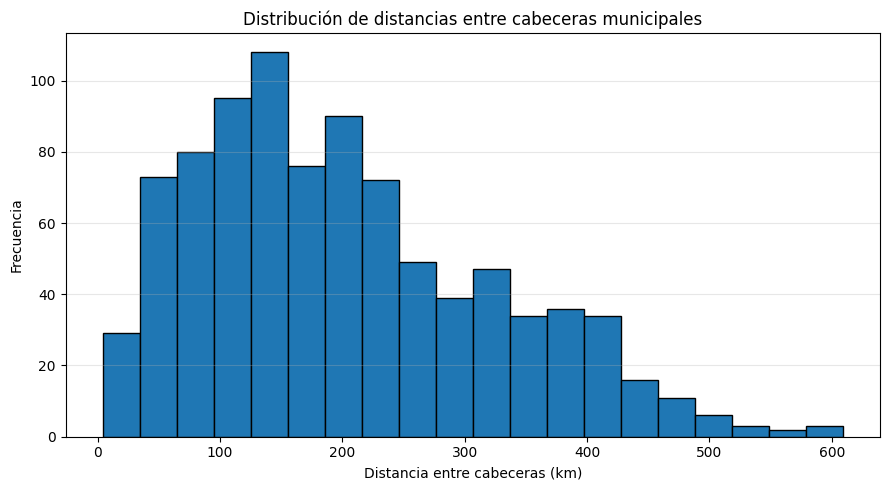

In [103]:
plt.figure(figsize=(9, 5))

plt.hist(
    distancias_unicas,
    bins=20,
    edgecolor="black"
)

plt.xlabel("Distancia entre cabeceras (km)")
plt.ylabel("Frecuencia")
plt.title("Distribución de distancias entre cabeceras municipales")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.savefig(
    os.path.join(
        RUTA_FIGURAS,
        "distribucion_distancias.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

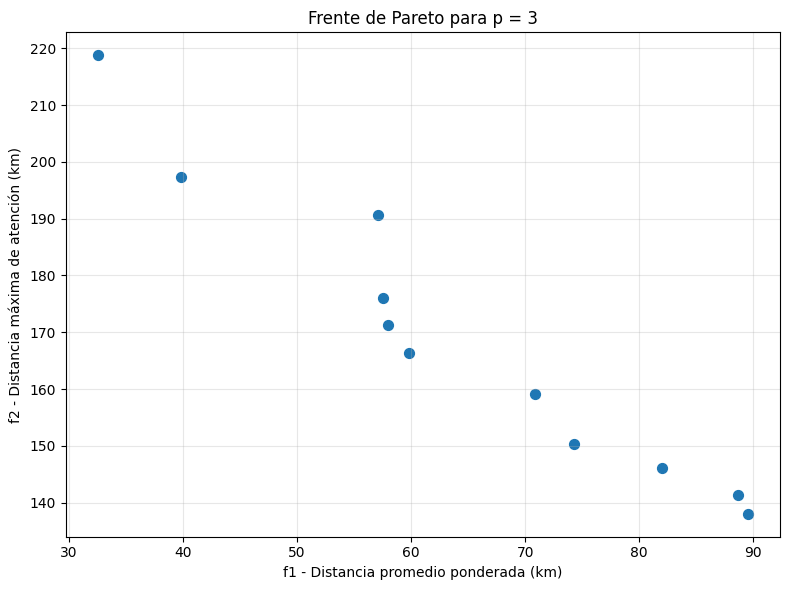

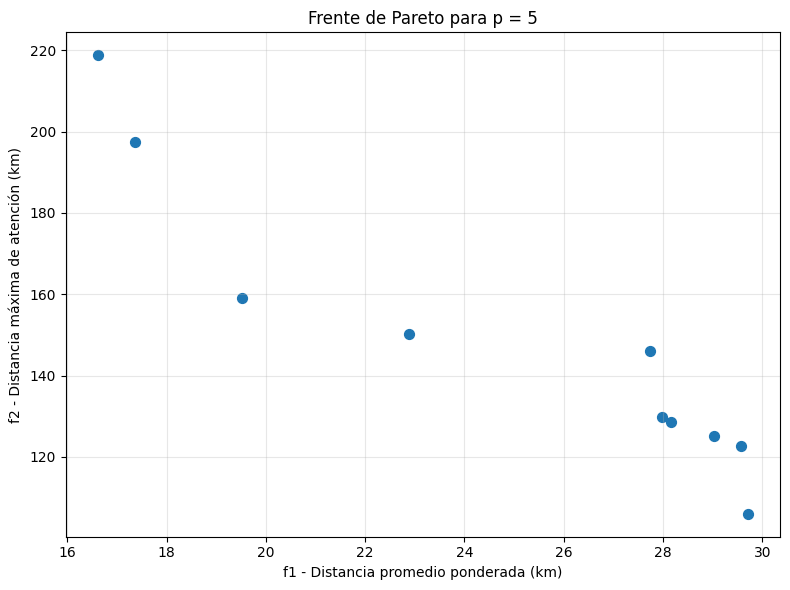

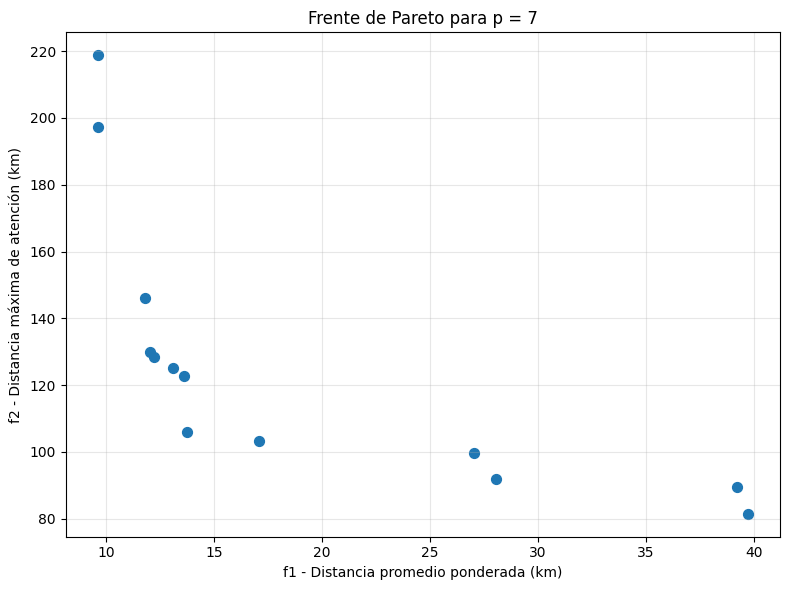

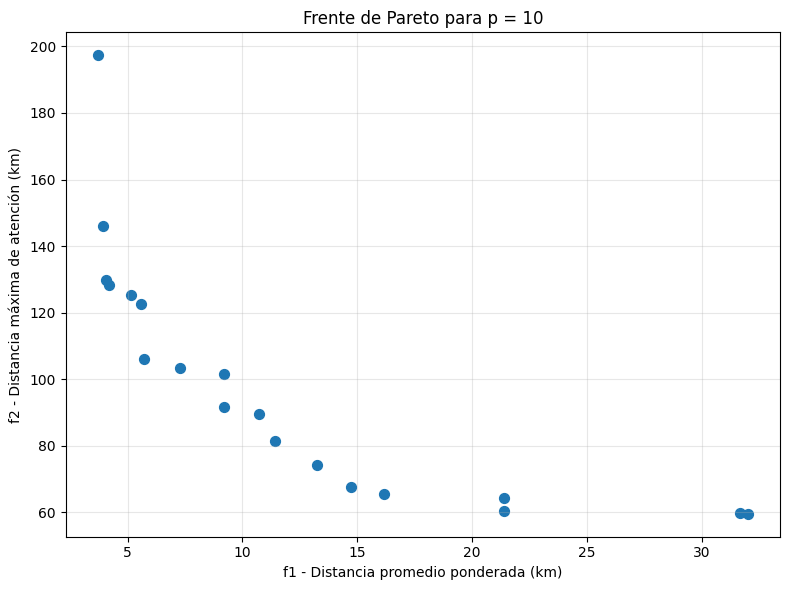

In [104]:
# ============================================================
# GUARDAR FRENTES DE PARETO
# ============================================================

for p in VALORES_P:

    F = resultados_nsga2[p]["F"]

    plt.figure(figsize=(8, 6))

    plt.scatter(
        F[:, 0],
        F[:, 1],
        s=50
    )

    plt.xlabel(
        "f1 - Distancia promedio ponderada (km)"
    )
    plt.ylabel(
        "f2 - Distancia máxima de atención (km)"
    )

    plt.title(
        f"Frente de Pareto para p = {p}"
    )

    plt.grid(alpha=0.3)
    plt.tight_layout()

    plt.savefig(
        os.path.join(
            RUTA_FIGURAS,
            f"pareto_p{p}.png"
        ),
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

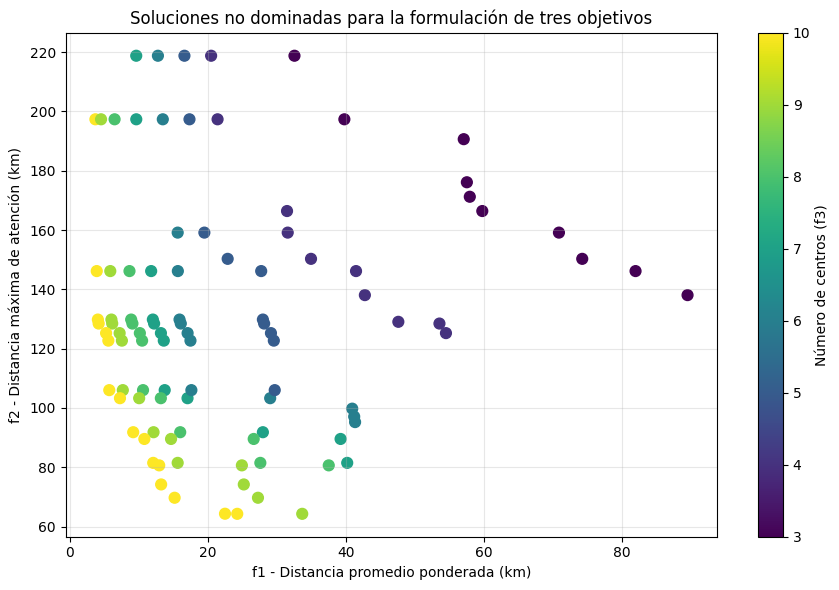

In [105]:
plt.figure(figsize=(9, 6))

scatter = plt.scatter(
    F_3obj[:, 0],
    F_3obj[:, 1],
    c=F_3obj[:, 2],
    s=60,
    cmap="viridis"
)

plt.xlabel(
    "f1 - Distancia promedio ponderada (km)"
)
plt.ylabel(
    "f2 - Distancia máxima de atención (km)"
)

plt.title(
    "Soluciones no dominadas para la formulación de tres objetivos"
)

cbar = plt.colorbar(scatter)
cbar.set_label("Número de centros (f3)")

plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    os.path.join(
        RUTA_FIGURAS,
        "pareto_3objetivos.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

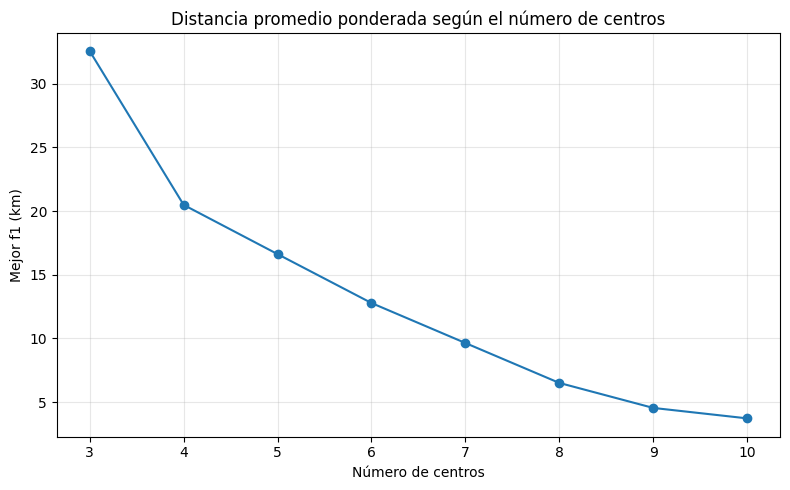

In [106]:
plt.figure(figsize=(8, 5))

plt.plot(
    resumen_3obj["f3_centros"],
    resumen_3obj["mejor_f1"],
    marker="o"
)

plt.xlabel("Número de centros")
plt.ylabel("Mejor f1 (km)")
plt.title(
    "Distancia promedio ponderada según el número de centros"
)

plt.xticks(resumen_3obj["f3_centros"])
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    os.path.join(
        RUTA_FIGURAS,
        "efecto_centros_f1.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

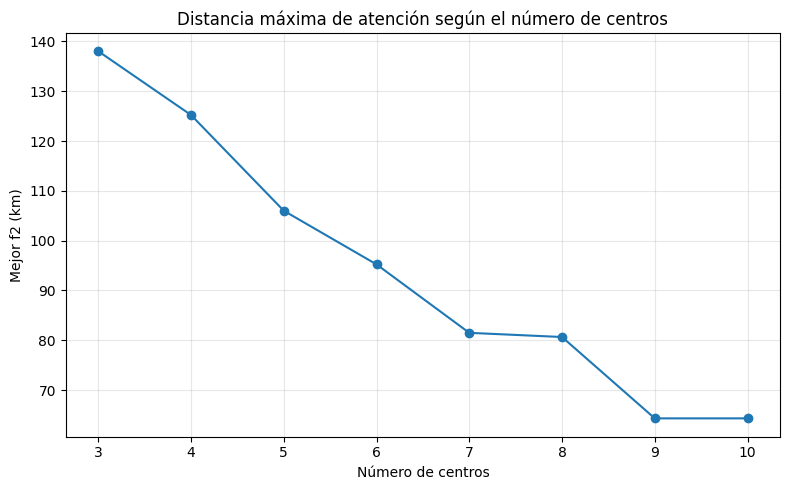

In [107]:
plt.figure(figsize=(8, 5))

plt.plot(
    resumen_3obj["f3_centros"],
    resumen_3obj["mejor_f2"],
    marker="o"
)

plt.xlabel("Número de centros")
plt.ylabel("Mejor f2 (km)")
plt.title(
    "Distancia máxima de atención según el número de centros"
)

plt.xticks(resumen_3obj["f3_centros"])
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    os.path.join(
        RUTA_FIGURAS,
        "efecto_centros_f2.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [108]:
# ============================================================
# VERIFICACIÓN DE ARCHIVOS GENERADOS
# ============================================================

print("=" * 60)
print("RESULTADOS CSV")
print("=" * 60)

for archivo in sorted(os.listdir(RUTA_RESULTADOS)):
    print(f"  {archivo}")


print("\n" + "=" * 60)
print("FIGURAS")
print("=" * 60)

for archivo in sorted(os.listdir(RUTA_FIGURAS)):
    print(f"  {archivo}")

RESULTADOS CSV
  baseline_aleatorio.csv
  baseline_produccion.csv
  baseline_voraz.csv
  comparacion_ga_baselines.csv
  mejores_soluciones_ga.csv
  pareto_2obj_p10.csv
  pareto_2obj_p3.csv
  pareto_2obj_p5.csv
  pareto_2obj_p7.csv
  pareto_3objetivos.csv
  resultados_ga.csv
  resumen_3objetivos.csv
  resumen_baseline_aleatorio.csv
  resumen_ga.csv
  resumen_pareto_2obj.csv
  wilcoxon_ga_vs_aleatorio.csv

FIGURAS
  distribucion_distancias.png
  efecto_centros_f1.png
  efecto_centros_f2.png
  nombre_figura.png
  pareto_3objetivos.png
  pareto_p10.png
  pareto_p3.png
  pareto_p5.png
  pareto_p7.png


### 12.10 Mapas de localización de centros

Para complementar el análisis numérico, se representan espacialmente las cabeceras municipales de Tamaulipas utilizando sus coordenadas geográficas.

El tamaño de cada punto se relaciona con la producción agrícola municipal, mientras que los municipios seleccionados como centros de acopio se resaltan mediante un símbolo diferente.

Estas visualizaciones permiten observar la distribución territorial de las soluciones y analizar si los centros seleccionados se concentran en las regiones de mayor producción o si también contribuyen a mejorar la cobertura geográfica.

In [109]:
def graficar_centros(x, titulo, nombre_archivo=None):

    x = np.asarray(x).astype(int)

    indices_centros = np.where(x == 1)[0]

    produccion = municipios["produccion_ton"].to_numpy()

    tamanos = 30 + 300 * (
        produccion / produccion.max()
    )

    plt.figure(figsize=(9, 8))

    # Todos los municipios
    plt.scatter(
        municipios["x_km"],
        municipios["y_km"],
        s=tamanos,
        alpha=0.5,
        label="Municipios"
    )

    # Centros seleccionados
    plt.scatter(
        municipios.iloc[indices_centros]["x_km"],
        municipios.iloc[indices_centros]["y_km"],
        s=180,
        marker="*",
        edgecolors="black",
        linewidths=1,
        label="Centros seleccionados"
    )

    # Etiquetar centros
    for idx in indices_centros:

        plt.text(
            municipios.iloc[idx]["x_km"],
            municipios.iloc[idx]["y_km"],
            municipios.iloc[idx]["municipio"],
            fontsize=8,
            ha="left",
            va="bottom"
        )

    plt.xlabel("Coordenada X (km)")
    plt.ylabel("Coordenada Y (km)")

    plt.title(titulo)

    # Muy importante para no deformar espacialmente el mapa
    plt.axis("equal")

    plt.legend()
    plt.grid(alpha=0.3)

    plt.tight_layout()

    if nombre_archivo is not None:

        plt.savefig(
            os.path.join(
                RUTA_FIGURAS,
                nombre_archivo
            ),
            dpi=300,
            bbox_inches="tight"
        )

    plt.show()

#### 12.10.1 Conversión a coordenadas cartesianas

In [110]:
# ============================================================
# CONVERSIÓN DE COORDENADAS GEOGRÁFICAS A CARTESIANAS
# ============================================================

R_TIERRA = 6371.0088  # km

# Coordenadas en radianes
lat_rad = np.radians(
    municipios["latitud"].to_numpy()
)

lon_rad = np.radians(
    municipios["longitud"].to_numpy()
)

# Punto de referencia
lat0 = np.mean(lat_rad)
lon0 = np.mean(lon_rad)

# Proyección equirectangular local
x_cart = (
    R_TIERRA
    * (lon_rad - lon0)
    * np.cos(lat0)
)

y_cart = (
    R_TIERRA
    * (lat_rad - lat0)
)

# Guardar coordenadas para visualización
municipios["x_km"] = x_cart
municipios["y_km"] = y_cart

display(
    municipios[
        [
            "municipio",
            "latitud",
            "longitud",
            "x_km",
            "y_km"
        ]
    ].head()
)

,municipio,latitud,longitud,x_km,y_km
0,Abasolo,24.060837,-98.374278,44.976197,-18.941495
1,Aldama,22.919305,-98.073712,75.453122,-145.874237
2,Altamira,22.391553,-97.936687,89.347245,-204.557663
3,Antiguo Morelos,22.549420,-99.083617,-26.949677,-187.003629
4,Burgos,24.946639,-98.799010,1.909031,79.555330


#### 12.10.2 Para $p=3$

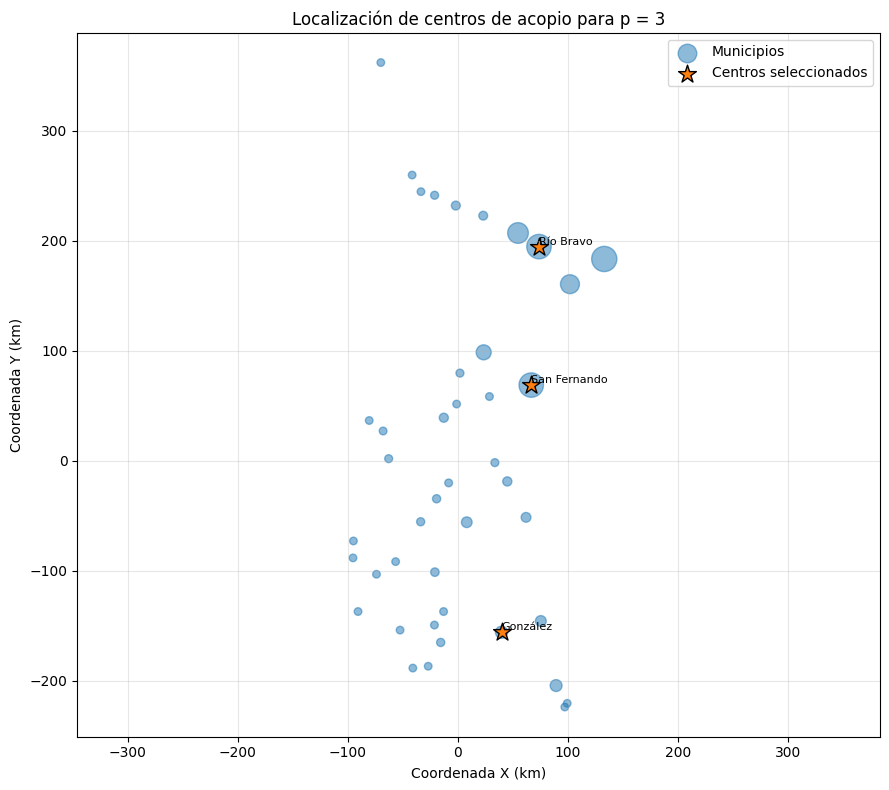

In [111]:
graficar_centros(
    mejores_x_ga[3],
    "Localización de centros de acopio para p = 3",
    "mapa_centros_p3.png"
)

#### 12.10.3 Para $p=5$

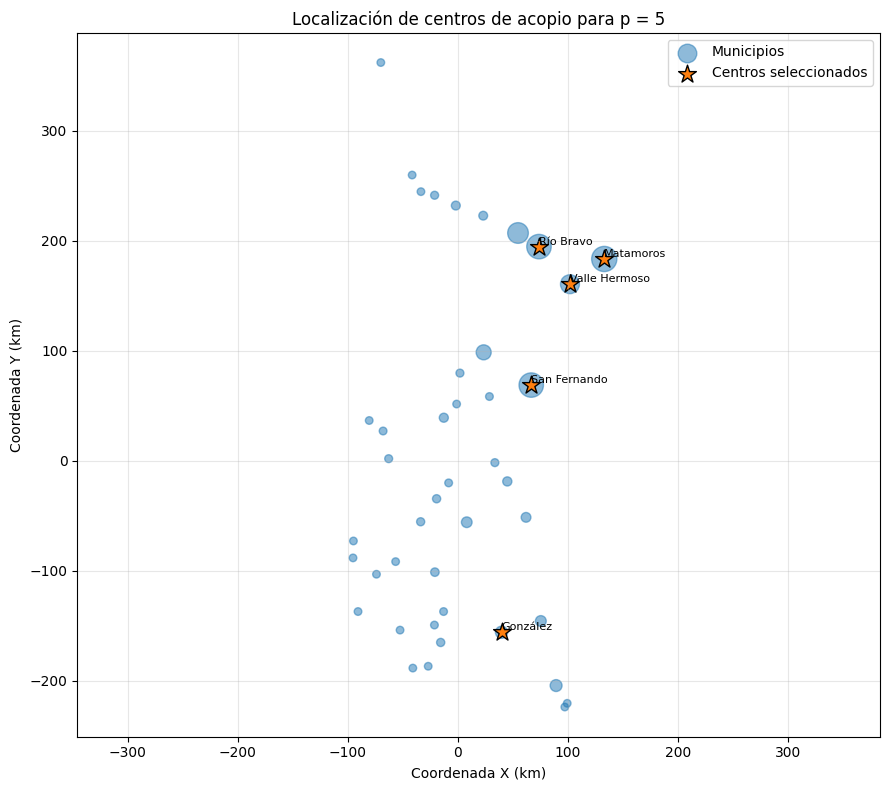

In [112]:
graficar_centros(
    mejores_x_ga[5],
    "Localización de centros de acopio para p = 5",
    "mapa_centros_p5.png"
)

#### 12.10.4 Para $p=7$

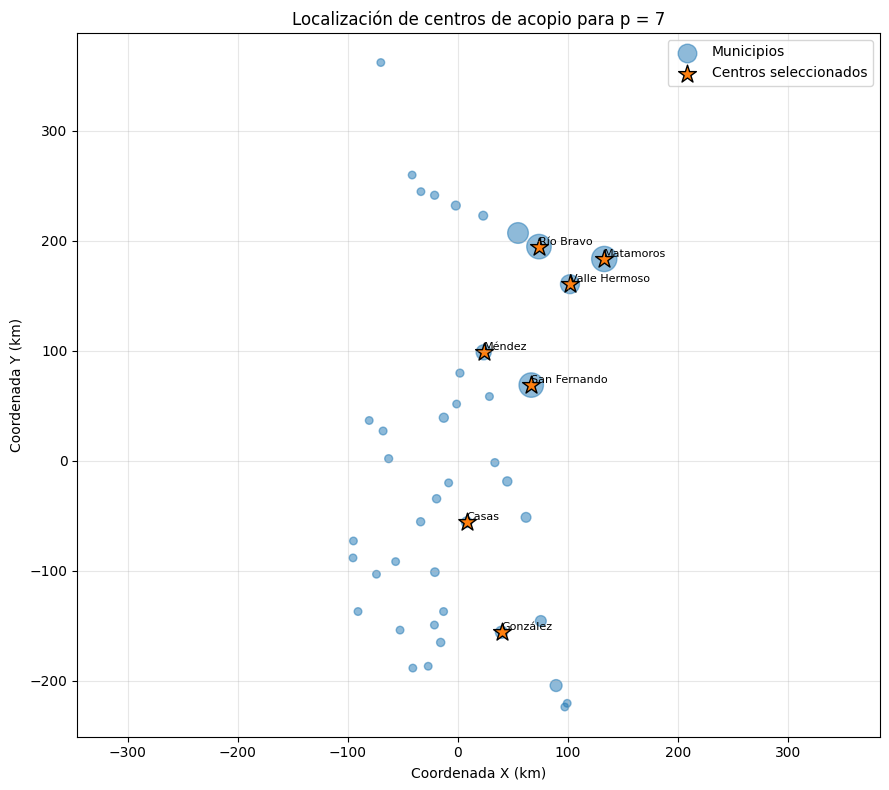

In [113]:
graficar_centros(
    mejores_x_ga[7],
    "Localización de centros de acopio para p = 7",
    "mapa_centros_p7.png"
)

#### 12.10.5 Para $p=10$

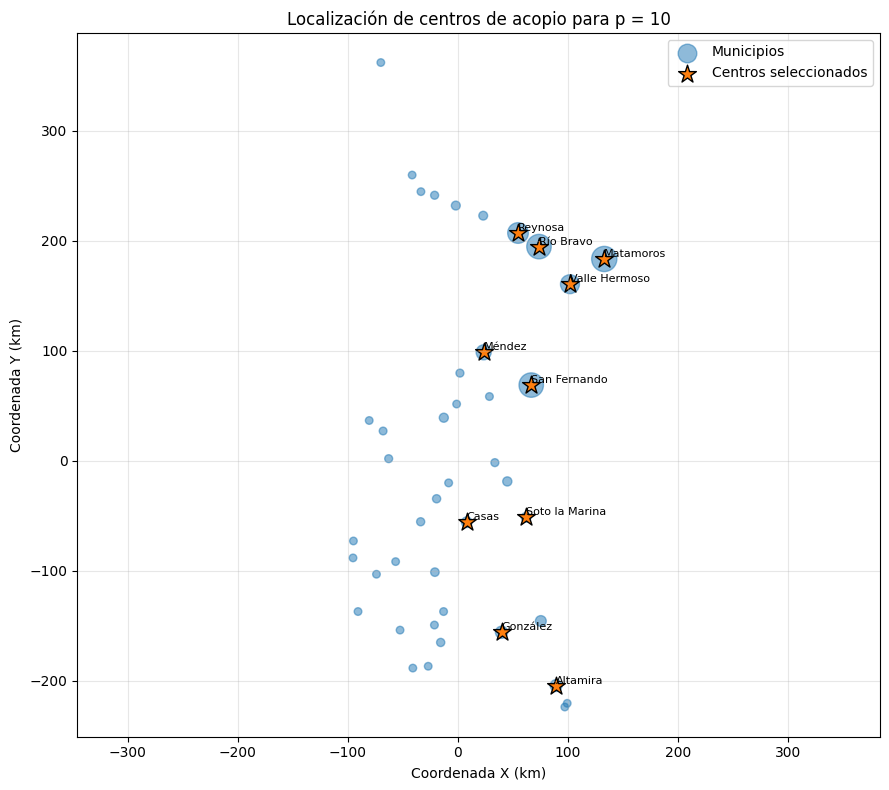

In [114]:
graficar_centros(
    mejores_x_ga[10],
    "Localización de centros de acopio para p = 10",
    "mapa_centros_p10.png"
)

## 13. Discusión general de resultados

Los experimentos realizados permiten analizar el problema de localización de centros de acopio desde tres perspectivas complementarias: eficiencia promedio, cobertura territorial y cantidad de infraestructura.

En la formulación monoobjetivo, el algoritmo genético mostró una reducción considerable de la distancia promedio ponderada respecto a la selección aleatoria. Para $p=3$, $p=5$, $p=7$ y $p=10$ se obtuvieron distancias de $32.56$, $16.62$, $9.64$ y $3.72$ km, respectivamente. En comparación, la selección aleatoria presentó valores medios de $120.18$, $78.45$, $73.97$ y $48.73$ km.

Las mejoras porcentuales del algoritmo genético respecto a la selección aleatoria fueron de $72.91\%$, $78.81\%$, $86.97\%$ y $92.36\%$, respectivamente. La prueba pareada de Wilcoxon produjo un valor de $p=9.31\times10^{-10}$ en los cuatro escenarios, proporcionando evidencia estadística de una diferencia favorable al algoritmo genético frente a esta línea base.

Sin embargo, la comparación con las demás heurísticas permite realizar una evaluación más completa. El algoritmo genético superó a la selección basada en producción para todos los valores de $p$. Frente a la heurística voraz, la principal diferencia se presentó para $p=3$, donde el GA obtuvo $32.56$ km frente a $38.02$ km. Para $p=5$, $p=7$ y $p=10$, ambos métodos alcanzaron el mismo valor de la función objetivo. Por lo tanto, aunque el GA mostró un desempeño elevado, la heurística voraz resultó altamente competitiva para esta instancia.

Los resultados multiobjetivo muestran que minimizar únicamente la distancia promedio ponderada no garantiza una cobertura territorial equilibrada. Las soluciones con menor $f_1$ pueden presentar valores elevados de $f_2$, por lo que algunos municipios permanecen considerablemente alejados de su centro más cercano. Los Frentes de Pareto obtenidos mediante NSGA-II permiten visualizar este intercambio y seleccionar alternativas de acuerdo con las prioridades del problema.

Al incorporar el número de instalaciones como tercer objetivo, se observa que incrementar el número de centros mejora progresivamente el desempeño, aunque aparecen rendimientos decrecientes. En particular, el mejor valor de $f_2$ disminuye hasta aproximadamente $64.31$ km con 9 centros y permanece en ese mismo valor con 10 centros. En cambio, $f_1$ continúa mejorando de $4.54$ km a $3.72$ km.

Por esta razón, no existe un único número de centros que pueda considerarse óptimo independientemente de las prioridades de decisión. Las configuraciones comprendidas entre 7 y 9 centros representan alternativas relevantes de compromiso. En particular, 9 centros resultan atractivos desde la perspectiva de cobertura territorial, debido a que alcanzan el mismo mejor valor de $f_2$ observado con 10 centros utilizando una instalación menos.

## 14. Conclusiones

El desarrollo del proyecto permitió formular y resolver el problema de localización de centros de acopio de sorgo grano en los 43 municipios de Tamaulipas mediante técnicas de Computación Evolutiva. La utilización de la producción municipal como ponderador permitió considerar no solamente la separación geográfica entre cabeceras, sino también la importancia productiva de cada municipio.

La formulación monoobjetivo mostró que aumentar el número de centros reduce considerablemente la distancia promedio ponderada. El algoritmo genético obtuvo valores de $32.56$, $16.62$, $9.64$ y $3.72$ km para $p=3$, $p=5$, $p=7$ y $p=10$, respectivamente. Asimismo, las 30 corridas convergieron al mismo valor para cada configuración, mostrando un comportamiento estable bajo los parámetros experimentales utilizados.

La comparación con las líneas base confirmó que el algoritmo genético mejora ampliamente la selección aleatoria y la estrategia basada exclusivamente en producción. La prueba de Wilcoxon confirmó una diferencia estadísticamente significativa frente a la selección aleatoria, con un valor de $p=9.31\times10^{-10}$. No obstante, la heurística voraz alcanzó resultados equivalentes al GA para $p=5$, $p=7$ y $p=10$, demostrando que una estrategia determinista sencilla puede ser altamente competitiva en esta instancia del problema.

La optimización multiobjetivo permitió demostrar que la eficiencia promedio y la cobertura territorial representan criterios parcialmente conflictivos. Las soluciones que minimizan $f_1$ no necesariamente minimizan $f_2$, por lo que los Frentes de Pareto proporcionan alternativas de decisión con diferentes niveles de compromiso entre ambos objetivos.

Al incorporar el número de centros como tercer objetivo se identificaron rendimientos decrecientes conforme aumenta la infraestructura. Los resultados sugieren que configuraciones entre 7 y 9 centros pueden representar compromisos razonables. Particularmente, 9 centros alcanzaron una distancia máxima mínima de aproximadamente $64.31$ km, igual a la obtenida con 10 centros, aunque con una instalación menos.

Finalmente, los resultados obtenidos deben interpretarse dentro de las simplificaciones del modelo. Las distancias utilizadas corresponden a distancias Haversine entre cabeceras municipales y no consideran la red carretera, tiempos de traslado, capacidad de almacenamiento, costos de construcción u operación. Por lo tanto, el modelo constituye una aproximación reproducible para estudiar el problema de localización y comparar estrategias evolutivas, mientras que una aplicación logística real requeriría incorporar restricciones y costos adicionales.